## Configuración e importación de librerías

Carga y manipulación de datos

In [1]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
import re
import shutil
from datetime import datetime
from pathlib import Path
import io
import time

Datos espaciales - vectores

In [2]:
from shapely.geometry import Point
import geopandas as gpd

Datos espaciales - raster y análisis espacial

In [3]:
import rasterio
from rasterio.merge import merge
import rioxarray
import xarray as xr
import xrspatial as xrs

Modelado y aprendizaje automático

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

Evaluación del modelo

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

Visualización

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch
import matplotlib.path as mpath
import contextily as cx

Herramientas científicas y soporte

In [7]:
from scipy.interpolate import griddata


Serialización y persistencia

In [8]:
import pickle

Fijar semillas aleatorias para reproducibilidad

In [9]:
seed = 42
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

Rutas a la carpetas de datos

In [11]:
DATA_DIR = Path("data")
DEM_DIR = DATA_DIR / "DEM"
FIRMS_DIR = DATA_DIR / "FIRMS" 
COBERTURA_DIR = DATA_DIR / "Cobertura_del_Suelo"
NDVI_DIR = DATA_DIR / "NDVI" 

try:
    HUMEDAD_CSV_PATH = list((DATA_DIR / "Humedad").glob("*.csv"))[0]
    PRECIPITATION_CSV_PATH = list((DATA_DIR / "Precipitation").glob("*.csv"))[0]
    TEMPERATURE_CSV_PATH = list((DATA_DIR / "Temperature").glob("*.csv"))[0]
    WIND_CSV_PATH = list((DATA_DIR / "Wind").glob("*.csv"))[0]
    print("Rutas a los archivos CSV climáticos encontradas exitosamente.")
except IndexError:
    print("ERROR CRÍTICO: No se encontró un archivo CSV en una de las carpetas climáticas. Revisa las carpetas.")
    exit() 

MERGED_DEM_PATH = DEM_DIR / "DEM_Cordillera.tif"
DEPARTAMENTO_SHP_PATH = DATA_DIR / "COORDILLERA" / "Departamento_Coordillera.shp"
VIAS_SHP_PATH = DATA_DIR / "COORDILLERA" / "Vias_principales_Coordillera.shp"
CIUDADES_SHP_PATH = DATA_DIR / "COORDILLERA" / "Ciudades_Coordillera.shp"
DISTRITOS_SHP_PATH = DATA_DIR / "COORDILLERA" / "Distritos_Coordillera.shp"

TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
OUTPUT_DIR = Path("outputs") / TIMESTAMP
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Los resultados se guardarán en: {OUTPUT_DIR}")

Rutas a los archivos CSV climáticos encontradas exitosamente.
Los resultados se guardarán en: outputs\2025-12-17_17-24-00


## Funciones auxiliares

In [ ]:
def load_firms_data(firms_folder, study_area_geom, crs):
    print("Cargando y FILTRANDO datos de focos de calor (FIRMS)...")
    firms_files = list(firms_folder.glob("**/*.csv"))
    if not firms_files: raise FileNotFoundError("No se encontraron archivos .csv")
    firms_df = pd.concat([pd.read_csv(f) for f in firms_files if 'focos_cordillera' not in f.name], ignore_index=True)
    total_inicial = len(firms_df)
    # --- FILTRO 1: TIPO DE INCENDIO (Solo vegetación) ---
    if 'type' in firms_df.columns:
        firms_df = firms_df[firms_df['type'] == 0]
    # --- FILTRO 2: CONFIANZA ---
    if 'confidence' in firms_df.columns:
        if firms_df['confidence'].dtype == 'object':
            firms_df = firms_df[firms_df['confidence'].isin(['n', 'h'])]
        else:
            firms_df = firms_df[firms_df['confidence'] >= 30]

    print(f"Filtro de calidad: Se eliminaron {total_inicial - len(firms_df)} falsos positivos o industriales.")

    firms_df['date'] = pd.to_datetime(firms_df['acq_date'])
    gdf_incendios = gpd.GeoDataFrame(firms_df, geometry=gpd.points_from_xy(firms_df.longitude, firms_df.latitude), crs="EPSG:4326").to_crs(crs)
    
    # Filtro espacial
    gdf_incendios = gdf_incendios[gdf_incendios.within(study_area_geom)]
    gdf_incendios['fire'] = 1
    
    print(f"Se cargaron {len(gdf_incendios)} puntos de incendios validados.")
    return gdf_incendios[['date', 'geometry', 'fire']]

def load_climate_data(temp_path, precip_path, wind_path, humidity_path):
    print("Cargando y combinando datos climáticos diarios...")
    temp_df = pd.read_csv(temp_path)[['datetime', 'temp_C']].rename(columns={'temp_C': 'temperature'})
    precip_df = pd.read_csv(precip_path)[['datetime', 'precip_mm']].rename(columns={'precip_mm': 'precipitation'})
    wind_df = pd.read_csv(wind_path)[['datetime', 'wind_speed_10m']].rename(columns={'wind_speed_10m': 'wind_speed'})
    hum_df = pd.read_csv(humidity_path)[['date', 'mean_RH']].rename(columns={'mean_RH': 'humidity'})
    
    for df in [temp_df, precip_df, wind_df, hum_df]:
        df['datetime'] = pd.to_datetime(df.get('datetime', df.get('date')))
    
    climate_dfs = [temp_df, precip_df, wind_df]
    weather_df = climate_dfs[0]
    for df_to_merge in climate_dfs[1:]: weather_df = pd.merge(weather_df, df_to_merge, on='datetime', how='outer')
    
    weather_df = weather_df.set_index('datetime')
    daily_weather = weather_df.resample('D').agg({'temperature': 'mean', 'precipitation': 'sum', 'wind_speed': 'mean'}).reset_index()
    final_weather_df = pd.merge(daily_weather, hum_df, on='datetime', how='outer').set_index('datetime').sort_index().ffill().bfill()
    print("Datos climáticos diarios cargados y combinados exitosamente.")
    return final_weather_df

def asignar_variables(df_puntos, dem_path, cobertura_folder, ndvi_mensual_folder, weather_df, vias_shp_path, ciudades_shp_path):
    """
    Asigna TODAS las variables predictoras
    """
    print("\n--- INICIANDO FASE DE ASIGNACIÓN DE VARIABLES ---")
    if df_puntos.empty: return df_puntos
    
    dataset = df_puntos.copy()
    dataset['year'] = dataset['date'].dt.year
    dataset['month'] = dataset['date'].dt.month
    
    # --- 3.1. Variables Topográficas ---
    print("Asignando variables topográficas...")
    # Abrimos el DEM original en su CRS geográfico (EPSG:4674)
    dem_geo = rioxarray.open_rasterio(dem_path).squeeze()
    
    # Extraemos la elevación del DEM original, ya que nuestros puntos están en ese CRS
    x_coords = xr.DataArray(dataset.geometry.x, dims="points")
    y_coords = xr.DataArray(dataset.geometry.y, dims="points")
    dataset['elevacion'] = dem_geo.sel(x=x_coords, y=y_coords, method="nearest").values
    
    # --- CORRECCIÓN CLAVE ---
    # Reproyectamos el DEM a un CRS en metros (UTM) SOLO para calcular pendiente y orientación
    print("Reproyectando DEM para cálculo de pendiente/orientación...")
    dem_utm = dem_geo.rio.reproject("EPSG:31981")
    
    # Calculamos pendiente y orientación sobre el DEM en metros
    slope_utm = xrs.slope(dem_utm)
    aspect_utm = xrs.aspect(dem_utm)
    
    # Para extraer los valores, necesitamos las coordenadas de nuestros puntos en el nuevo CRS (UTM)
    dataset_utm = dataset.to_crs("EPSG:31981")
    x_coords_utm = xr.DataArray(dataset_utm.geometry.x, dims="points")
    y_coords_utm = xr.DataArray(dataset_utm.geometry.y, dims="points")
    
    # Extraemos los valores de pendiente y orientación
    dataset['pendiente'] = slope_utm.sel(x=x_coords_utm, y=y_coords_utm, method="nearest").values
    dataset['orientacion'] = aspect_utm.sel(x=x_coords_utm, y=y_coords_utm, method="nearest").values

    # El resto del código de esta sección no cambia
    bins = [-1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 361]; labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
    dataset['orientacion_cat'] = pd.cut(dataset['orientacion'], bins=bins, labels=labels, right=False, ordered=False).cat.add_categories("Plano").fillna("Plano")

    # --- El resto de la función (Cobertura, NDVI, Clima, Proximidad) permanece idéntico ---
    print("Asignando Cobertura del Suelo por año...")
    dataset['cobertura'] = np.nan
    for year in sorted(dataset['year'].unique()):
        cobertura_path = cobertura_folder / f"Cobertura_Cordillera_{year}.tif"
        if cobertura_path.exists():
            cobertura_raster = rioxarray.open_rasterio(cobertura_path, masked=True).squeeze(drop=True)
            idx_year = dataset['year'] == year
            if idx_year.any():
                group_year_proj = dataset.loc[idx_year].to_crs(cobertura_raster.rio.crs)
                x_coords_year = xr.DataArray(group_year_proj.geometry.x, dims="points")
                y_coords_year = xr.DataArray(group_year_proj.geometry.y, dims="points")
                dataset.loc[idx_year, 'cobertura'] = cobertura_raster.sel(x=x_coords_year, y=y_coords_year, method="nearest").values

    print("Asignando NDVI desde archivos mensuales...")
    dataset['ndvi'] = np.nan
    NDVI_SCALE_FACTOR = 0.0001
    ndvi_files_map = { (int(f.stem.split('_')[2]), int(f.stem.split('_')[3])): f 
                       for f in ndvi_mensual_folder.glob("NDVI_MODIS_*.tif") }
    
    for (year, month), group in dataset.groupby(['year', 'month']):
        if (year, month) in ndvi_files_map:
            raster_path = ndvi_files_map[(year, month)]
            raster = rioxarray.open_rasterio(raster_path, masked=True).squeeze(drop=True)
            group_proj = group.to_crs(raster.rio.crs)
            x_coords_group = xr.DataArray(group_proj.geometry.x, dims="points")
            y_coords_group = xr.DataArray(group_proj.geometry.y, dims="points")
            raw_values = raster.sel(x=x_coords_group, y=y_coords_group, method="nearest").values
            scaled_values = np.where(~np.isnan(raw_values), raw_values * NDVI_SCALE_FACTOR, np.nan)
            dataset.loc[group.index, 'ndvi'] = scaled_values

    print("Asignando variables meteorológicas...")
    dataset = dataset.sort_values('date')
    dataset = pd.merge_asof(dataset, weather_df, left_on='date', right_index=True, direction='backward')
    
    print("Añadiendo características de proximidad...")
    projected_crs = "EPSG:31981"
    dataset_proj = dataset.to_crs(projected_crs)
    vias_gdf = gpd.read_file(VIAS_SHP_PATH).to_crs(projected_crs)
    ciudades_gdf = gpd.read_file(CIUDADES_SHP_PATH).to_crs(projected_crs)
    dataset['dist_vias'] = dataset_proj.geometry.distance(vias_gdf.union_all())
    dataset['dist_ciudades'] = dataset_proj.geometry.distance(ciudades_gdf.union_all())

    print("Asignación de variables completada.")
    return dataset

## Generación de la muestra y asignación de datos

In [ ]:
print("\n--- INICIANDO FASE DE PREPARACIÓN DE DATOS ---")
area_estudio_gdf = gpd.read_file(DEPARTAMENTO_SHP_PATH)
CRS_REFERENCE = area_estudio_gdf.crs.to_string()
study_area_bounds = area_estudio_gdf.total_bounds
study_area_polygon = area_estudio_gdf.union_all()
print("\nCreando máscara de zonas inflamables a partir de la Cobertura del Suelo...")

# Define la ruta a solo UNO de tus archivos de cobertura, el más reciente servirá.
# Necesitamos la estructura, no los valores anuales.
COBERTURA_PATH_BASE = COBERTURA_DIR / "Cobertura_Cordillera_2023.tif" # O el año que sea

# Define las clases de cobertura que consideras "inflamables"
CLASES_INFLAMABLES = [3.0, 6.0, 11.0, 12.0, 15.0]  # <-- ¡¡¡AJUSTA ESTOS VALORES!!! Son los que identificaste en QGIS.

# Carga el raster
with rasterio.open(COBERTURA_PATH_BASE) as src:
    # Lee el raster como un array de numpy
    cobertura_array = src.read(1)
    transform = src.transform
    crs = src.crs

    # Crea una máscara booleana: True donde la clase es inflamable
    mask = np.isin(cobertura_array, CLASES_INFLAMABLES)

    # Vectoriza el raster: convierte los píxeles True en polígonos
    # Esto crea una lista de (geometría, valor) para cada polígono de píxeles conectados
    shapes = list(rasterio.features.shapes(mask.astype('uint8'), mask=mask, transform=transform))

shapes_geojson = [{'geometry': geom, 'properties': {'value': val}} for geom, val in shapes]
# 2. Ahora creamos el GeoDataFrame desde esta lista bien formateada
zonas_inflamables_gdf = gpd.GeoDataFrame.from_features(shapes_geojson, crs=crs)

# 3. La disolución funciona igual que antes
zonas_inflamables_poligono = zonas_inflamables_gdf.unary_union

print("Máscara de zonas inflamables creada exitosamente.")
print(f"Área de estudio definida. CRS: {CRS_REFERENCE}")

puntos_positivos = load_firms_data(FIRMS_DIR, study_area_polygon, CRS_REFERENCE)

print("\nGenerando muestras negativas (no-incendios) con muestreo de fondo inteligente...")
n_negativos = len(puntos_positivos) if len(puntos_positivos) > 0 else 1000
puntos_negativos_list = []
minx, miny, maxx, maxy = study_area_bounds
start_date, end_date = puntos_positivos['date'].min(), puntos_positivos['date'].max()
dias_rango = (end_date - start_date).days
projected_crs = "EPSG:31981"
puntos_positivos_proj = puntos_positivos.to_crs(projected_crs)
incendios_por_dia_proj = {d: g[['geometry']] for d, g in puntos_positivos_proj.groupby(puntos_positivos_proj['date'].dt.date)}
intentos = 0
max_intentos = n_negativos * 500 # Aumentamos los intentos porque será más difícil encontrar puntos

while len(puntos_negativos_list) < n_negativos:
    intentos += 1
    if intentos > max_intentos:
        print(f"\nADVERTENCIA: Se superó el número máximo de intentos ({max_intentos}). Se generaron {len(puntos_negativos_list)} puntos.")
        break
    
    # 1. Generar un punto aleatorio dentro de los límites del departamento
    random_point_geo = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
    
    # 2. PRIMER FILTRO: ¿Está el punto dentro del área de estudio Y dentro de una zona inflamable?
    #    Usamos 'within' que es más rápido que la comprobación de cobertura del raster.
    if not random_point_geo.within(zonas_inflamables_poligono):
        continue  # Si no está en una zona inflamable, se descarta y se prueba de nuevo.

    # 3. Si pasa el primer filtro, se procede a la comprobación de proximidad a incendios
    random_date = start_date + pd.to_timedelta(np.random.randint(0, dias_rango + 1), unit='d')
    es_valido = True
    ventana_temporal_dias = 3
    distancia_min_metros = 15000

    # Proyectar el punto aleatorio a UTM para el cálculo de distancia
    # Hacemos esto solo para los puntos que ya son candidatos, es más eficiente.
    random_point_gds_proj = gpd.GeoSeries([random_point_geo], crs=CRS_REFERENCE).to_crs(projected_crs)

    for i in range(-ventana_temporal_dias, ventana_temporal_dias + 1):
        check_date = (random_date + pd.to_timedelta(i, unit='d')).date()
        if check_date in incendios_por_dia_proj:
            if incendios_por_dia_proj[check_date].distance(random_point_gds_proj.iloc[0]).min() < distancia_min_metros:
                es_valido = False
                break
    
    # 4. Si el punto es válido en ambos filtros, se añade a la lista
    if es_valido:
        puntos_negativos_list.append({'date': random_date, 'geometry': random_point_geo, 'fire': 0})
        if len(puntos_negativos_list) % 200 == 0:
            print(f"  ... {len(puntos_negativos_list)}/{n_negativos} puntos negativos generados. (Tasa de éxito: {len(puntos_negativos_list)/intentos:.2%})")
if not puntos_negativos_list:
    print("\nERROR CRÍTICO: No se pudo generar ningún punto negativo.")
    exit()

puntos_negativos = gpd.GeoDataFrame(puntos_negativos_list, crs=CRS_REFERENCE)
sample = pd.concat([puntos_positivos, puntos_negativos], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
print(f"\nMuestra final generada con {len(sample)} observaciones.")

weather_data = load_climate_data(TEMPERATURE_CSV_PATH, PRECIPITATION_CSV_PATH, WIND_CSV_PATH, HUMEDAD_CSV_PATH)
full_dataset = asignar_variables(sample, MERGED_DEM_PATH, COBERTURA_DIR, NDVI_DIR, weather_data, VIAS_SHP_PATH, CIUDADES_SHP_PATH)



--- INICIANDO FASE DE PREPARACIÓN DE DATOS ---

Creando máscara de zonas inflamables a partir de la Cobertura del Suelo...


C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\2473378066.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  zonas_inflamables_poligono = zonas_inflamables_gdf.unary_union


Máscara de zonas inflamables creada exitosamente.
Área de estudio definida. CRS: EPSG:4674
Cargando datos de focos de calor (FIRMS)...
Se cargaron y filtraron 14078 puntos de incendios.

Generando muestras negativas (no-incendios) con muestreo de fondo inteligente...
  ... 200/14078 puntos negativos generados. (Tasa de éxito: 23.34%)
  ... 400/14078 puntos negativos generados. (Tasa de éxito: 22.59%)
  ... 600/14078 puntos negativos generados. (Tasa de éxito: 22.08%)
  ... 800/14078 puntos negativos generados. (Tasa de éxito: 21.95%)
  ... 1000/14078 puntos negativos generados. (Tasa de éxito: 22.12%)
  ... 1200/14078 puntos negativos generados. (Tasa de éxito: 22.14%)
  ... 1400/14078 puntos negativos generados. (Tasa de éxito: 21.94%)
  ... 1600/14078 puntos negativos generados. (Tasa de éxito: 21.88%)
  ... 1800/14078 puntos negativos generados. (Tasa de éxito: 21.87%)
  ... 2000/14078 puntos negativos generados. (Tasa de éxito: 21.87%)
  ... 2200/14078 puntos negativos generados. (

## Depuración y modelado

In [14]:
print("\n--- INICIANDO FASE DE DEPURACIÓN ---")
print("Valores nulos por columna ANTES de depurar:\n", full_dataset.isnull().sum())
datos_depurados = full_dataset.dropna()
print(f"\nRegistros ANTES de depurar: {len(full_dataset)} | DESPUÉS de depurar: {len(datos_depurados)}")

if len(datos_depurados) < 100:
    print("\nERROR CRÍTICO: No hay suficientes datos después de la depuración.")
    exit()

columnas_modelo = ['elevacion', 'pendiente', 'orientacion_cat', 'cobertura', 'ndvi', 'temperature', 'precipitation', 'wind_speed', 'humidity', 'dist_vias', 'dist_ciudades', 'fire']
datos_modelo = datos_depurados[columnas_modelo].copy()
datos_modelo['cobertura'] = datos_modelo['cobertura'].astype('category')
print("\nInfo del dataset final:\n"); datos_modelo.info()
print("\nVista previa del dataset final:\n", datos_modelo.head())
buffer = io.StringIO()
datos_modelo.info(buf=buffer)
info_string = buffer.getvalue()
head_string = datos_modelo.head().to_string()
ruta_resumen_dataset = OUTPUT_DIR / "dataset_summary.txt"
with open(ruta_resumen_dataset, "w") as f:
    f.write("=========================================\n")
    f.write(" RESUMEN DEL DATASET FINAL (datos_modelo)\n")
    f.write("=========================================\n\n")
    f.write("--- DataFrame .info() ---\n")
    f.write(info_string)
    f.write("\n\n--- DataFrame .head() ---\n")
    f.write(head_string)
    f.write("\n")
print(f"Resumen del dataset guardado en: {ruta_resumen_dataset}")



--- INICIANDO FASE DE DEPURACIÓN ---
Valores nulos por columna ANTES de depurar:
 date               0
date_x             0
geometry           0
fire               0
year               0
month              0
elevacion          0
pendiente          0
orientacion        0
orientacion_cat    0
cobertura          0
ndvi               0
temperature        0
precipitation      0
wind_speed         0
date_y             0
humidity           0
dist_vias          0
dist_ciudades      0
dtype: int64

Registros ANTES de depurar: 28156 | DESPUÉS de depurar: 28156

Info del dataset final:

<class 'pandas.core.frame.DataFrame'>
Index: 28156 entries, 20966 to 22829
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   elevacion        28156 non-null  int16   
 1   pendiente        28156 non-null  float32 
 2   orientacion_cat  28156 non-null  category
 3   cobertura        28156 non-null  category
 4   ndvi             2815

## Modelado con validación espacial

In [ ]:
print("\n--- INICIANDO FASE DE MODELADO CON VALIDACIÓN ESPACIAL ---")
"""
Separar datos con un BLOQUE ESPACIAL
Tras el análisis de sanidad, se observó que una división por longitud (Este/Oeste)
creaba conjuntos de datos muy diferentes. Se procede a dividir por latitud (Norte/Sur)
para obtener una partición más balanceada y una evaluación del modelo más robusta.
Se usará un corte del 50% para un equilibrio aún mayor.
"""
# Añadimos las coordenadas 'y' (latitud) al DataFrame para poder filtrar
datos_modelo['latitud'] = datos_depurados.geometry.y

# Calculamos el punto de corte (el percentil 50 de las latitudes)
split_point = datos_modelo['latitud'].quantile(0.5)

# Creamos los conjuntos de entrenamiento y prueba usando la columna 'latitud'
train_df = datos_modelo[datos_modelo['latitud'] <= split_point]
test_df = datos_modelo[datos_modelo['latitud'] > split_point]

# Eliminar la columna 'latitud' que ya no necesitamos para el entrenamiento
train_df = train_df.drop(columns=['latitud'])
test_df = test_df.drop(columns=['latitud'])

print(f"División espacial por LATITUD: {len(train_df)} muestras para entrenar, {len(test_df)} para probar.")

# Comprobar que ambas clases están presentes en ambos conjuntos
if train_df['fire'].nunique() < 2 or test_df['fire'].nunique() < 2:
    print("\nADVERTENCIA: La división espacial resultó en un conjunto sin ambas clases. Prueba un punto de corte diferente (ej. 0.5) o considera una estrategia de bloques más compleja.")
else:
    X_train = train_df.drop('fire', axis=1)
    y_train = train_df['fire']
    X_test = test_df.drop('fire', axis=1)
    y_test = test_df['fire']

    # --- 5.2. Pipeline de preprocesamiento (sin cambios) ---
    numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ], remainder='drop')

    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPClassifier
    from sklearn.ensemble import StackingClassifier
    
    # Intentamos importar las librerías de Boosting (si fallan, avisa)
    try:
        from xgboost import XGBClassifier
        from lightgbm import LGBMClassifier
        from catboost import CatBoostClassifier
    except ImportError:
        print("ERROR CRÍTICO: Faltan librerías. Ejecuta: pip install xgboost lightgbm catboost")
        raise

    # 2. Definición del Nivel 0 (9 Modelos Base)
    level_0_estimators = [
        ('rf', RandomForestClassifier(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=seed)),
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss', n_jobs=-1, random_state=seed)),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, n_jobs=-1, random_state=seed, verbose=-1)),
        ('svm', CalibratedClassifierCV(LinearSVC(dual='auto', random_state=seed), cv=3)),
        ('knn', KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
        ('cat', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, verbose=0, random_state=seed)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(50, 25), activation='relu', alpha=0.001, max_iter=500, early_stopping=True, random_state=seed))
    ]

    # 3. Definición del Nivel 1 (Meta-Modelo)
    level_1_meta_model = LogisticRegression(solver='lbfgs', C=1.0, random_state=seed)

    # 4. Creación del Stacking Classifier
    stacking_model = StackingClassifier(
        estimators=level_0x_estimators,
        final_estimator=level_1_meta_model,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1,
        passthrough=False 
    )

    # 5. Pipeline Final
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', stacking_model)])
    # --- 5.4. Entrenar y Evaluar ---
    print("\nEntrenando el modelo de Stacking...")
    full_pipeline.fit(X_train, y_train)
    print("Entrenamiento completado.")




--- INICIANDO FASE DE MODELADO CON VALIDACIÓN ESPACIAL ---
División espacial por LATITUD: 14079 muestras para entrenar, 14077 para probar.

Entrenando el modelo de Stacking...
Entrenamiento completado.


### EVALUACIÓN UNIFICADA (MÉTRICAS + TIEMPO + MEMORIA)

In [ ]:


print("\n--- RECOPILANDO MÉTRICAS PARA TOPSIS Y COMPARATIVA ---")

# Preparamos los datos transformados para los modelos base (para ser justos)
X_test_trans = full_pipeline.named_steps['preprocessor'].transform(X_test)
stacking_clf = full_pipeline.named_steps['classifier']

# Diccionario con todos los modelos
modelos_a_evaluar = {name.upper(): model for name, model in stacking_clf.named_estimators_.items()}
modelos_a_evaluar['STACKING'] = full_pipeline # El pipeline completo usa X_test sin transformar

resultados_globales = []

for nombre, modelo in modelos_a_evaluar.items():
    print(f"Evaluando: {nombre}...")
    
    # 1. Medir Tiempo de Inferencia y Predicción
    start_time = time.time()
    
    if nombre == 'STACKING':
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_pred = modelo.predict(X_test_trans)
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(X_test_trans)[:, 1]
        else:
            # Fallback para modelos como SVM (si no estuviera calibrado)
            d = modelo.decision_function(X_test_trans)
            y_proba = (d - d.min()) / (d.max() - d.min())
            
    end_time = time.time()
    tiempo_segundos = end_time - start_time
    
    # 2. Calcular Métricas de Clasificación
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # Specificity (TN / (TN + FP))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # 3. Medir Memoria (Estimación serialización)
    try:
        peso_mb = len(pickle.dumps(modelo)) / (1024 * 1024)
    except:
        peso_mb = 0

    resultados_globales.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'ROC_AUC': auc,
        'Specificity': spec,
        'Tiempo_Inferencia': tiempo_segundos,
        'Memoria_MB': peso_mb,
        'y_proba': y_proba # Guardamos para graficar luego
    })

df_resultados = pd.DataFrame(resultados_globales).set_index('Modelo')
print("Evaluación completada.")


--- RECOPILANDO MÉTRICAS PARA TOPSIS Y COMPARATIVA ---
Evaluando: RF...
Evaluando: XGB...
Evaluando: LGBM...


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluando: SVM...
Evaluando: KNN...
Evaluando: CAT...
Evaluando: MLP...
Evaluando: STACKING...


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluación completada.


### Implementación de Metodología AHP/Experto + TOPSIS

In [32]:
print("\n--- 4. CÁLCULO DE RANKING TOPSIS (ENFOQUE AHP / CRITERIO EXPERTO) ---")

# -------------------------------------------------------------------------
# BLOQUE DE JUSTIFICACIÓN CIENTÍFICA (AHP)
# -------------------------------------------------------------------------

justificacion_ahp = [
    {
        "Criterio": "Recall (Sensibilidad)",
        "Peso": 0.35, 
        "Prioridad AHP": "Muy Alta (Crítica)",
        "Justificación": "Minimizar Falsos Negativos es la prioridad absoluta. Se aumentó el peso para asegurar la detección."
    },
    {
        "Criterio": "F1-Score",
        "Peso": 0.25, 
        "Prioridad AHP": "Alta",
        "Justificación": "Métrica de balance. Se prioriza sobre la Precisión pura para tener un modelo robusto."
    },
    {
        "Criterio": "ROC AUC",
        "Peso": 0.15,
        "Prioridad AHP": "Alta",
        "Justificación": "Discriminación global del modelo."
    },
    {
        "Criterio": "Precision",
        "Peso": 0.10,
        "Prioridad AHP": "Media",
        "Justificación": "Reducción de falsas alarmas."
    },
    {
        "Criterio": "Specificity",
        "Peso": 0.08, 
        "Prioridad AHP": "Media",
        "Justificación": "Capacidad de descartar zonas seguras."
    },
    {
        "Criterio": "Accuracy",
        "Peso": 0.05,
        "Prioridad AHP": "Baja",
        "Justificación": "Referencial."
    },
    {
        "Criterio": "Tiempo Inferencia",
        "Peso": 0.01, 
        "Prioridad AHP": "Irrelevante",
        "Justificación": "Con transformación logarítmica, el impacto es marginal. Se prioriza calidad."
    },
    {
        "Criterio": "Memoria MB",
        "Peso": 0.01, 
        "Prioridad AHP": "Irrelevante",
        "Justificación": "Con transformación logarítmica, el impacto es marginal. Hardware sobra."
    }
]

df_justificacion = pd.DataFrame(justificacion_ahp)
print("\n>>> MATRIZ DE PONDERACIÓN Y JUSTIFICACIÓN (Metodología AHP):")
display(df_justificacion.style.hide(axis="index"))

# Verificación de seguridad
suma_pesos = df_justificacion['Peso'].sum()
print(f"Suma de pesos: {suma_pesos:.2f} (Debe ser 1.0)")
if not np.isclose(suma_pesos, 1.0):
    print("¡ALERTA! Los pesos no suman 1.0. Revisa los decimales.")

print("-" * 80)

# -------------------------------------------------------------------------
# ALGORITMO TOPSIS
# -------------------------------------------------------------------------

# Columnas a usar
cols_topsis = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'Specificity', 'Tiempo_Inferencia', 'Memoria_MB']
X_matriz = df_resultados[cols_topsis].copy()

# --- CORRECCIÓN MATEMÁTICA LOGARÍTMICA ---
X_matriz['Tiempo_Inferencia'] = np.log1p(X_matriz['Tiempo_Inferencia'])
X_matriz['Memoria_MB'] = np.log1p(X_matriz['Memoria_MB'])
print(">> Se aplicó transformación Logarítmica a Tiempo y Memoria para una comparación justa.")

# A. Definir Tipos de Criterio
# 1 = Beneficio, -1 = Costo
criteria_types = np.array([1, 1, 1, 1, 1, 1, -1, -1])

# B. Normalización Vectorial
X_norm = X_matriz / np.sqrt((X_matriz**2).sum())

# C. ASIGNACIÓN DE PESOS (AUTOMÁTICA DESDE LA TABLA)
# Ahora tomamos los pesos DIRECTAMENTE del dataframe, así siempre coinciden.
weights = np.array(df_justificacion['Peso'].tolist())

# D. Matriz Ponderada y Distancias
V = X_norm * weights
ideal_pos = []
ideal_neg = []

for i, col in enumerate(X_matriz.columns):
    if criteria_types[i] == 1: # Beneficio
        ideal_pos.append(V[col].max())
        ideal_neg.append(V[col].min())
    else: # Costo
        ideal_pos.append(V[col].min())
        ideal_neg.append(V[col].max())

dist_pos = np.sqrt(((V - ideal_pos) ** 2).sum(axis=1))
dist_neg = np.sqrt(((V - ideal_neg) ** 2).sum(axis=1))

# E. Score Final
topsis_score = dist_neg / (dist_pos + dist_neg)

# F. Tabla Final
df_ranking = df_resultados[cols_topsis].copy()
df_ranking['TOPSIS_Score'] = topsis_score
df_ranking['Rank'] = df_ranking['TOPSIS_Score'].rank(ascending=False).astype(int)
df_ranking = df_ranking.sort_values('Rank')

print("\n=== RANKING FINAL DE MODELOS (TOPSIS) ===")
display(df_ranking.style.background_gradient(cmap='RdYlGn', subset=['TOPSIS_Score', 'Recall']))


--- 4. CÁLCULO DE RANKING TOPSIS (ENFOQUE AHP / CRITERIO EXPERTO) ---

>>> MATRIZ DE PONDERACIÓN Y JUSTIFICACIÓN (Metodología AHP):


Criterio,Peso,Prioridad AHP,Justificación
Recall (Sensibilidad),0.350000,Muy Alta (Crítica),Minimizar Falsos Negativos es la prioridad absoluta. Se aumentó el peso para asegurar la detección.
F1-Score,0.250000,Alta,Métrica de balance. Se prioriza sobre la Precisión pura para tener un modelo robusto.
ROC AUC,0.150000,Alta,Discriminación global del modelo.
Precision,0.100000,Media,Reducción de falsas alarmas.
Specificity,0.080000,Media,Capacidad de descartar zonas seguras.
Accuracy,0.050000,Baja,Referencial.
Tiempo Inferencia,0.010000,Irrelevante,"Con transformación logarítmica, el impacto es marginal. Se prioriza calidad."
Memoria MB,0.010000,Irrelevante,"Con transformación logarítmica, el impacto es marginal. Hardware sobra."


Suma de pesos: 1.00 (Debe ser 1.0)
--------------------------------------------------------------------------------
>> Se aplicó transformación Logarítmica a Tiempo y Memoria para una comparación justa.

=== RANKING FINAL DE MODELOS (TOPSIS) ===


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,Tiempo_Inferencia,Memoria_MB,TOPSIS_Score,Rank
Modelo,,,,,,,,,,
LGBM,0.878312,0.903319,0.892730,0.897993,0.946981,0.856686,0.410999,0.332310,0.873169,1
XGB,0.869646,0.889111,0.894269,0.891683,0.940993,0.832712,0.227996,0.150128,0.824497,2
CAT,0.866875,0.885319,0.893914,0.889596,0.939113,0.826319,0.912997,0.039839,0.737150,3
MLP,0.855083,0.863152,0.901373,0.881849,0.928311,0.785651,0.024000,0.068736,0.644502,4
SVM,0.853804,0.854810,0.911082,0.882050,0.928829,0.767892,0.041004,0.002432,0.613465,5
RF,0.868438,0.901095,0.876983,0.888876,0.941626,0.855621,0.587995,16.601445,0.551641,6
STACKING,0.860553,0.868981,0.903860,0.886077,0.935481,0.795596,5.061030,20.105312,0.286902,7
KNN,0.838318,0.850489,0.886337,0.868043,0.911870,0.766294,5.677001,2.900875,0.256601,8


### VISUALIZACIÓN DE RESULTADOS

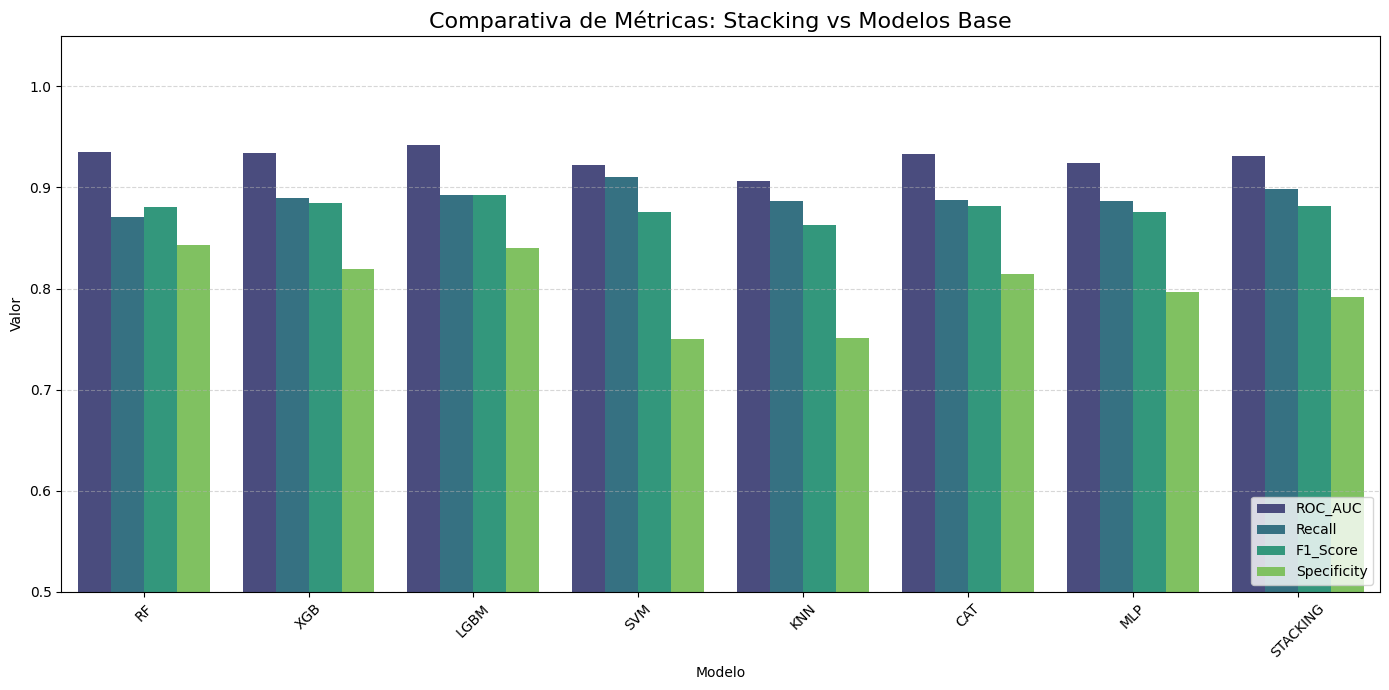

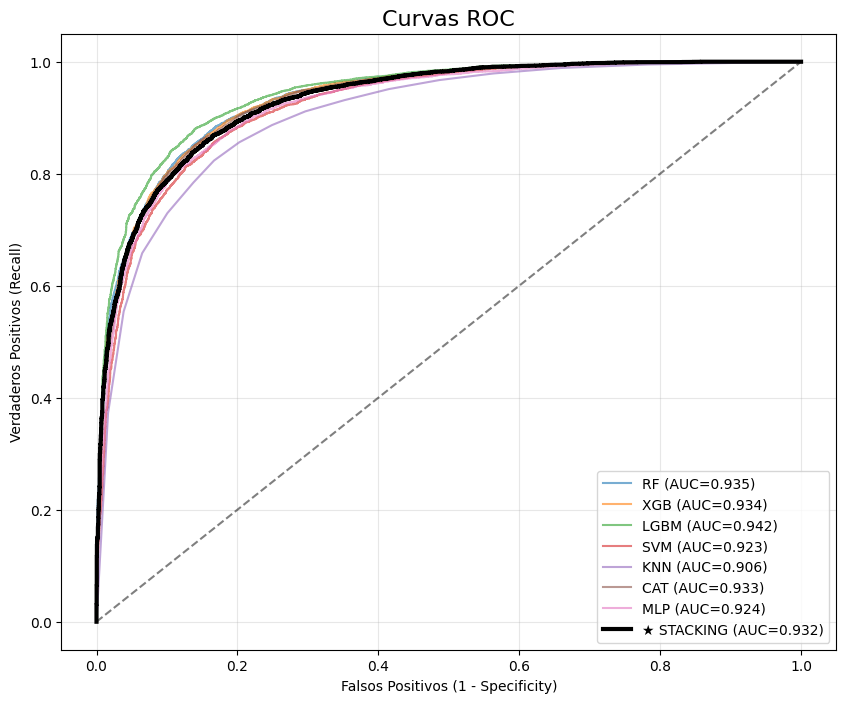

In [50]:
# A. Gráfico de Barras: Métricas Clave
metrics_plot = ['ROC_AUC', 'Recall', 'F1_Score', 'Specificity']
df_plot = df_resultados[metrics_plot].reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparativa de Métricas: Stacking vs Modelos Base', fontsize=16)
plt.ylim(0.5, 1.05) # Ajustar zoom si los valores son altos
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# B. Curvas ROC
plt.figure(figsize=(10, 8))
for modelo_name, row in df_resultados.iterrows():
    y_prob = row['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = row['ROC_AUC']
    
    # Destacar Stacking
    if modelo_name == 'STACKING':
        plt.plot(fpr, tpr, label=f"★ {modelo_name} (AUC={auc_val:.3f})", linewidth=3, color='black', zorder=10)
    else:
        plt.plot(fpr, tpr, label=f"{modelo_name} (AUC={auc_val:.3f})", alpha=0.6)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Falsos Positivos (1 - Specificity)')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.title('Curvas ROC', fontsize=16)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Análisis de sanidad de la muestra y la partición espacial


--- INICIANDO ANÁLISIS DE SANIDAD DE LA MUESTRA ---

Generando gráficos para analizar la distribución de las muestras...


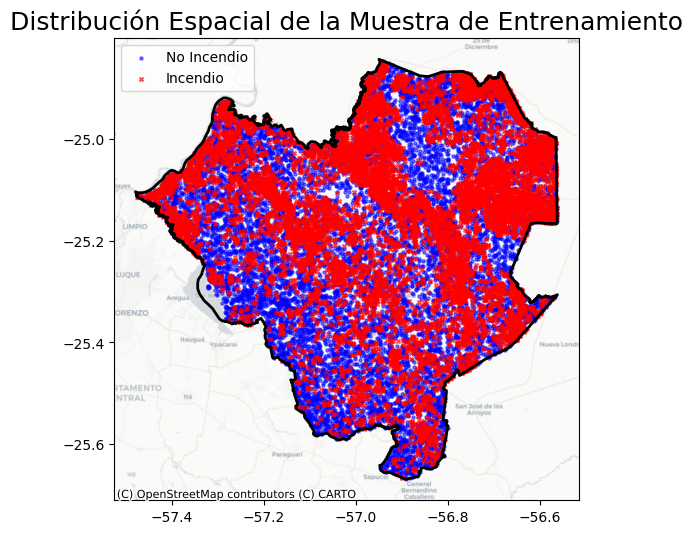

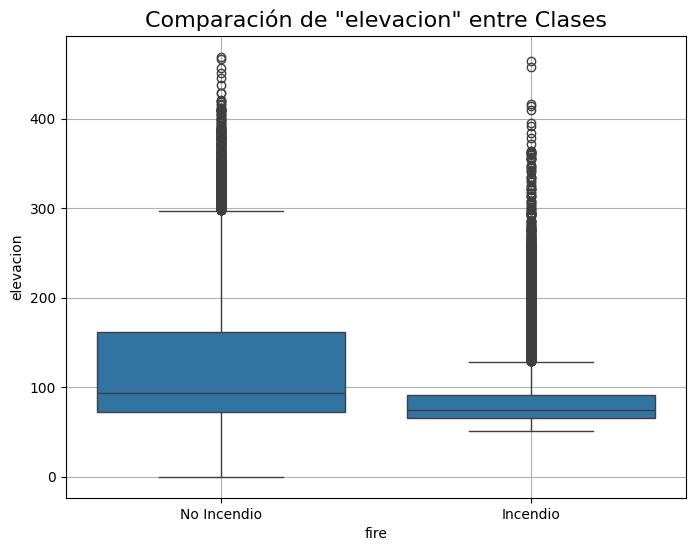

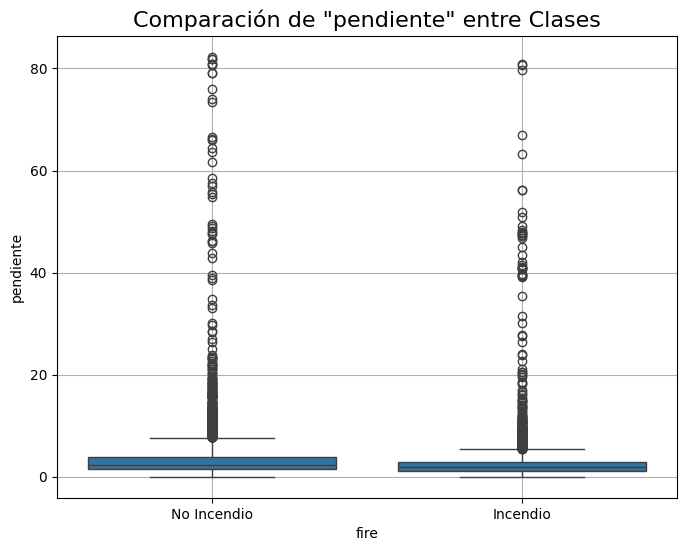

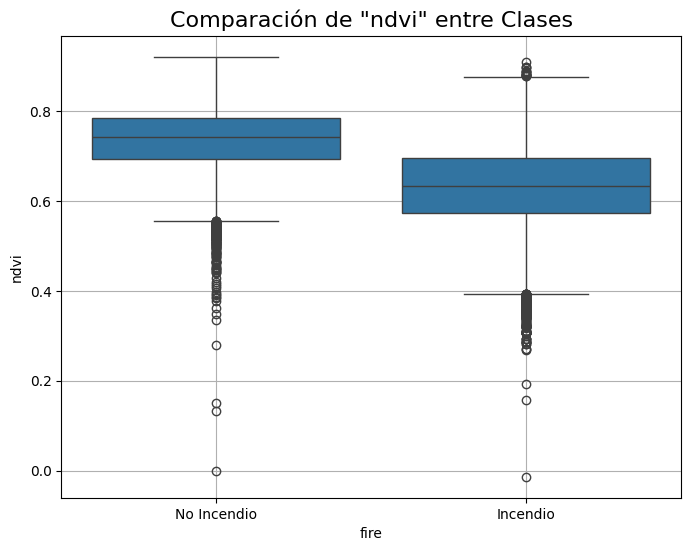

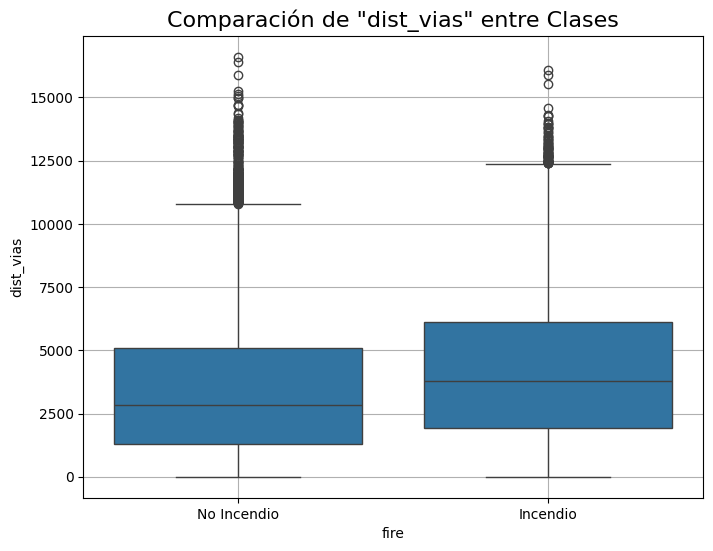

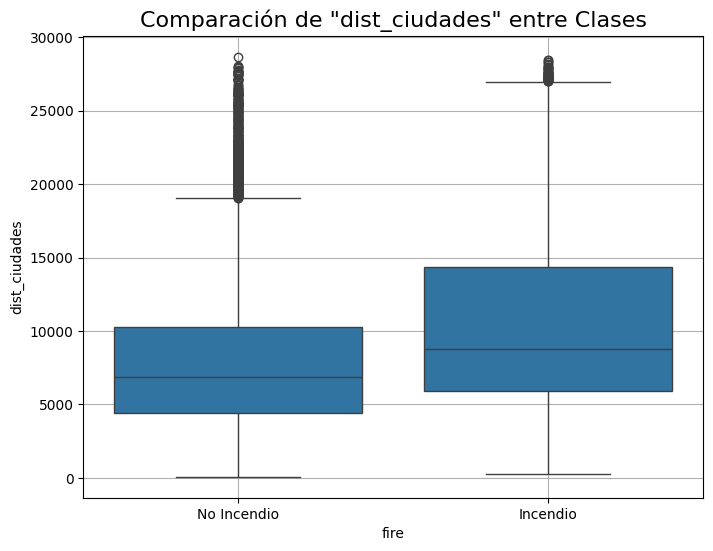


Generando mapa de la partición Train/Test espacial...


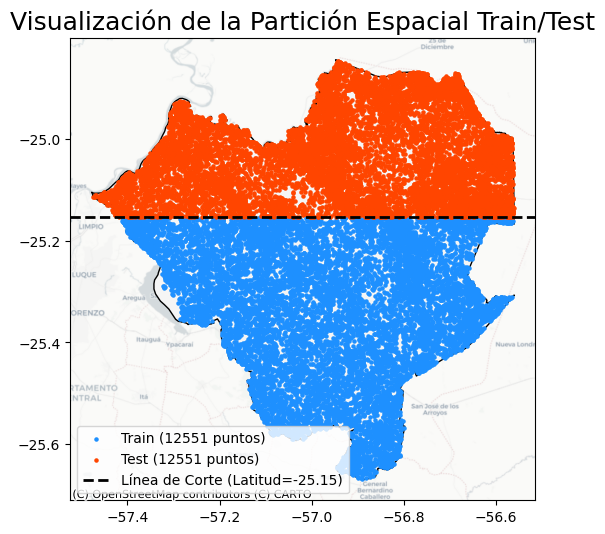

--- ANÁLISIS DE SANIDAD COMPLETADO ---


In [ ]:
print("\n--- INICIANDO ANÁLISIS DE SANIDAD DE LA MUESTRA ---")

# --- Hipótesis 1: ¿Son las muestras negativas "demasiado fáciles"? ---
print("\nGenerando gráficos para analizar la distribución de las muestras...")

# Gráfico 1: Distribución Espacial de la Muestra Completa
# Esto nos permite ver si los puntos negativos (azules) están distribuidos de forma similar a los positivos (rojos).
# fig, ax = plt.subplots(1, 1, figsize=(15, 12))
fig, ax = plt.subplots(figsize=(10, 6))

area_estudio_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=2, zorder=3)
datos_depurados[datos_depurados['fire'] == 0].plot(ax=ax, marker='o', color='blue', markersize=5, label='No Incendio', alpha=0.5)
datos_depurados[datos_depurados['fire'] == 1].plot(ax=ax, marker='x', color='red', markersize=8, label='Incendio', alpha=0.7)
ax.set_title('Distribución Espacial de la Muestra de Entrenamiento', fontsize=18)
ax.legend()
cx.add_basemap(ax, crs=area_estudio_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
plt.savefig(OUTPUT_DIR / "mapa_distribucion_muestra.png", dpi=300)
plt.show()

# Gráfico 2: Comparación de la Distribución de Variables Clave
# Comparamos las distribuciones para "Incendio" vs "No Incendio".
# Si las cajas son muy diferentes, los puntos negativos son "fáciles".
variables_a_comparar = ['elevacion', 'pendiente', 'ndvi', 'dist_vias', 'dist_ciudades']
for var in variables_a_comparar:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='fire', y=var, data=datos_modelo)
    plt.title(f'Comparación de "{var}" entre Clases', fontsize=16)
    plt.xticks([0, 1], ['No Incendio', 'Incendio'])
    plt.grid(True)
    plt.savefig(OUTPUT_DIR / f'boxplot_{var}_vs_fire.png', dpi=300)
    plt.show()


# --- Hipótesis 2: ¿Es la partición espacial representativa? ---
print("\nGenerando mapa de la partición Train/Test espacial...")

# Recreamos la división (ahora por LATITUD) para obtener los índices y geometrías
temp_df_vis = datos_depurados.copy()
temp_df_vis['latitud'] = temp_df_vis.geometry.y # Usamos la coordenada 'y' (latitud)
split_point_vis = temp_df_vis['latitud'].quantile(0.5) # Usamos el mismo corte 50/50
train_indices = temp_df_vis[temp_df_vis['latitud'] <= split_point_vis].index
test_indices = temp_df_vis[temp_df_vis['latitud'] > split_point_vis].index

train_gdf_vis = datos_depurados.loc[train_indices]
test_gdf_vis = datos_depurados.loc[test_indices]

# Gráfico 3: Mapa de la Partición Espacial
# fig, ax = plt.subplots(1, 1, figsize=(15, 12))
fig, ax = plt.subplots(figsize=(10, 6))

area_estudio_gdf.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=1)
train_gdf_vis.plot(ax=ax, marker='o', color='dodgerblue', markersize=5, label=f'Train ({len(train_gdf_vis)} puntos)')
test_gdf_vis.plot(ax=ax, marker='o', color='orangered', markersize=5, label=f'Test ({len(test_gdf_vis)} puntos)')

# Dibujar la línea de división HORIZONTAL
ax.axhline(y=split_point_vis, color='black', linestyle='--', linewidth=2, label=f'Línea de Corte (Latitud={split_point_vis:.2f})')

ax.set_title('Visualización de la Partición Espacial Train/Test', fontsize=18)
ax.legend()
cx.add_basemap(ax, crs=area_estudio_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
plt.savefig(OUTPUT_DIR / "mapa_particion_espacial.png", dpi=300)
plt.show()

print("--- ANÁLISIS DE SANIDAD COMPLETADO ---")


## Análisis de sanidad de la partición espacial (Gráficos)


--- INICIANDO ANÁLISIS DE SANIDAD DE LA PARTICIÓN TRAIN/TEST ---
Comparando la distribución de variables entre el conjunto de entrenamiento y prueba...


C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


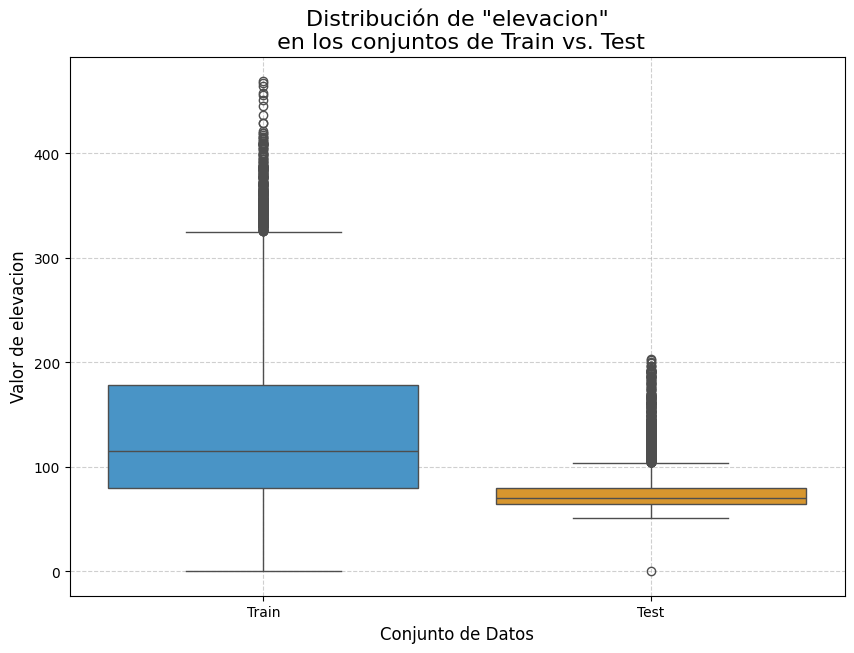

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


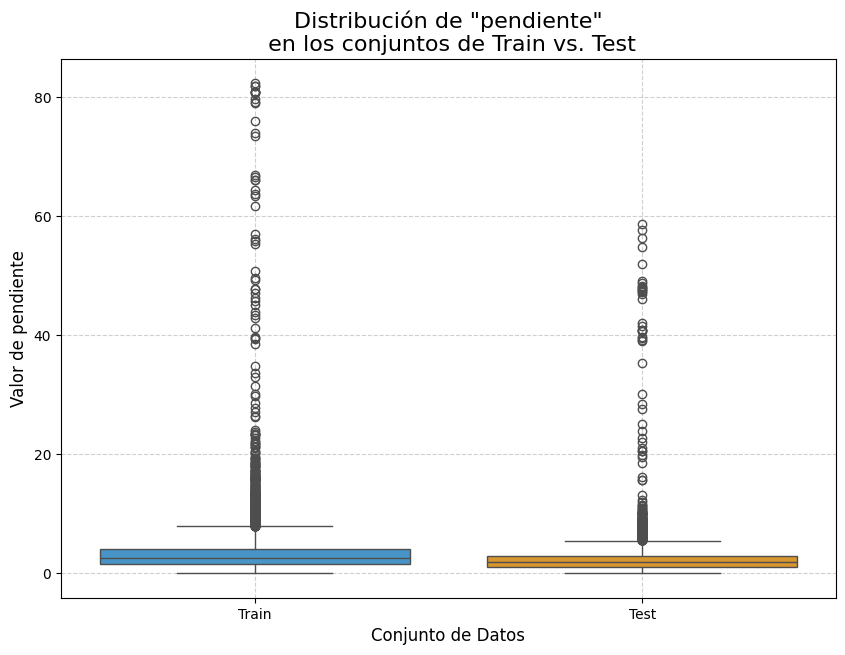

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


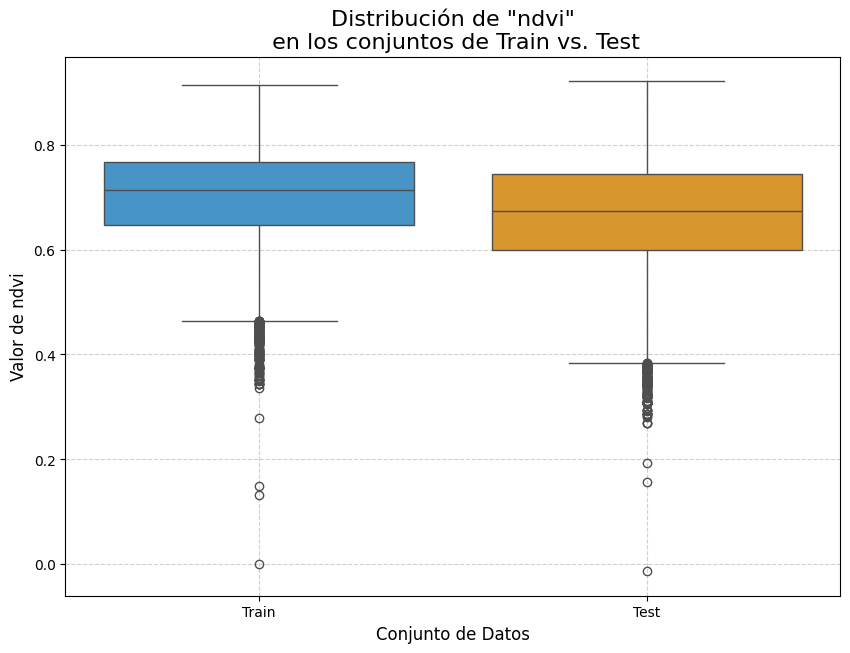

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


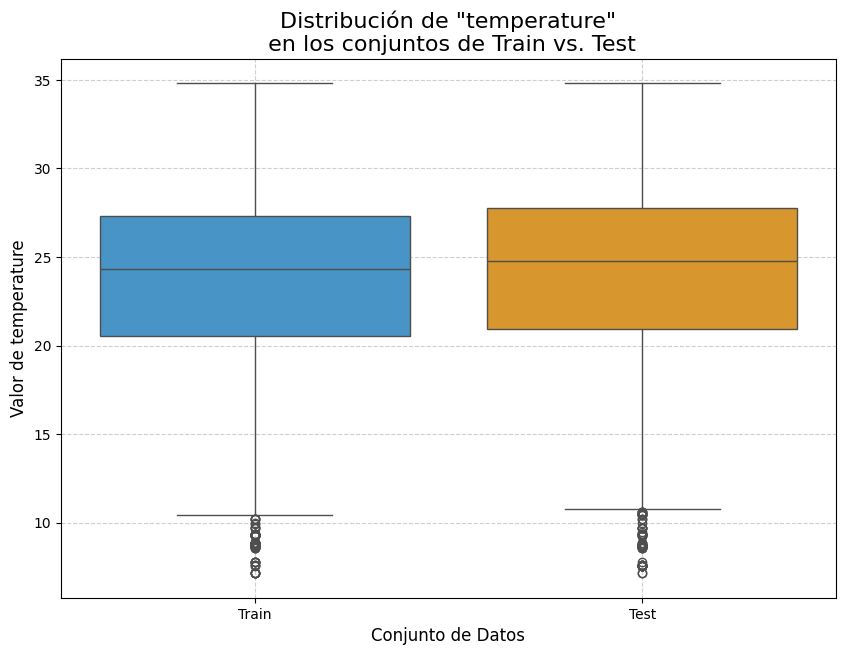

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


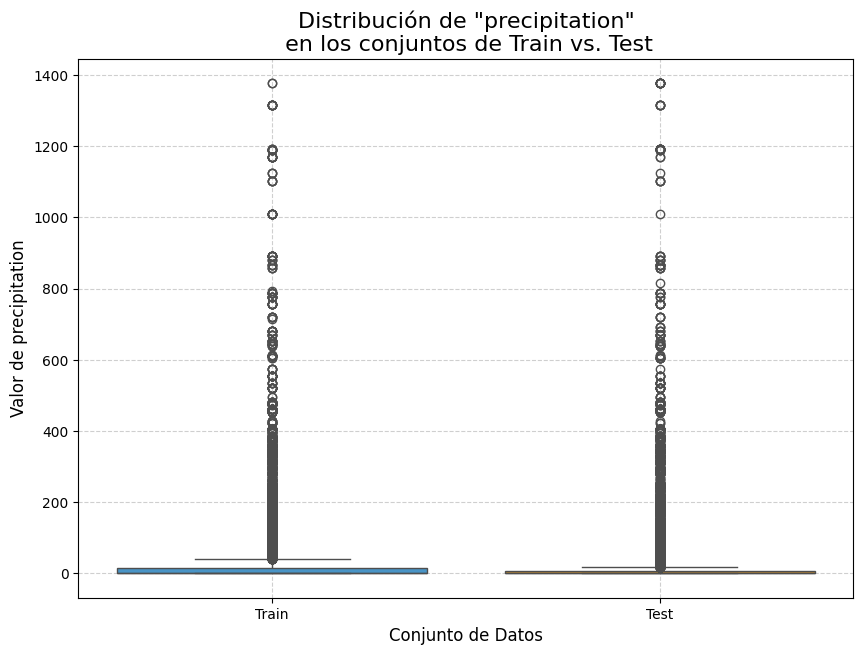

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


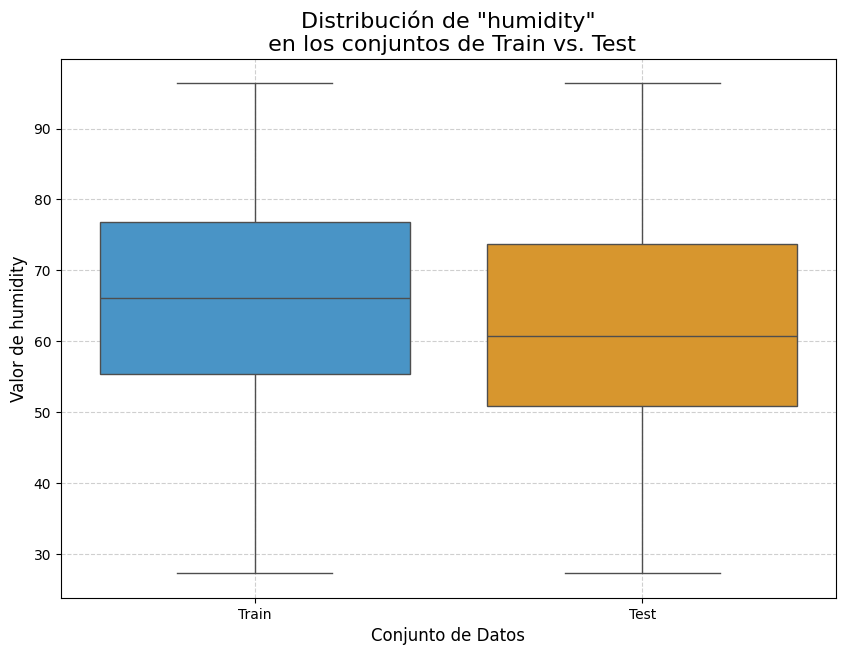

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


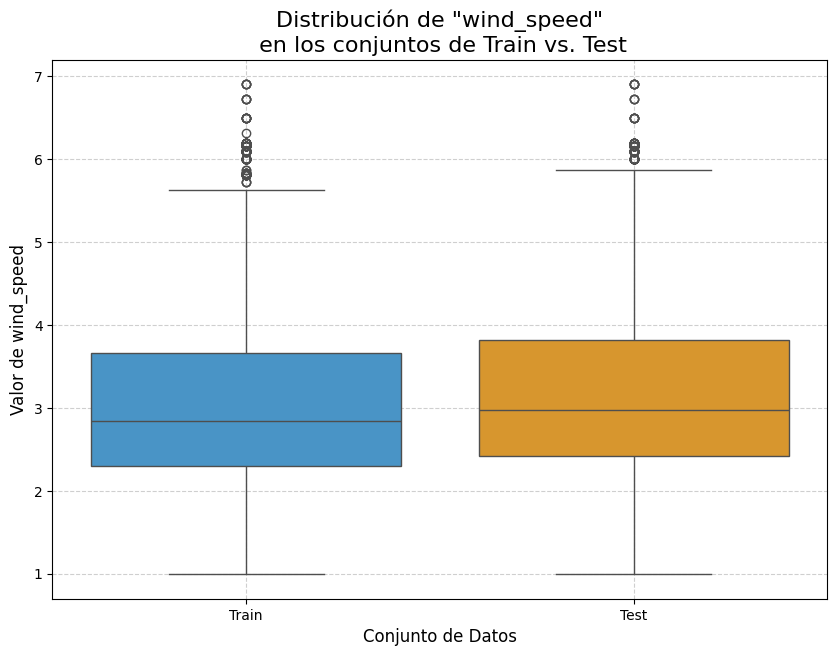

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


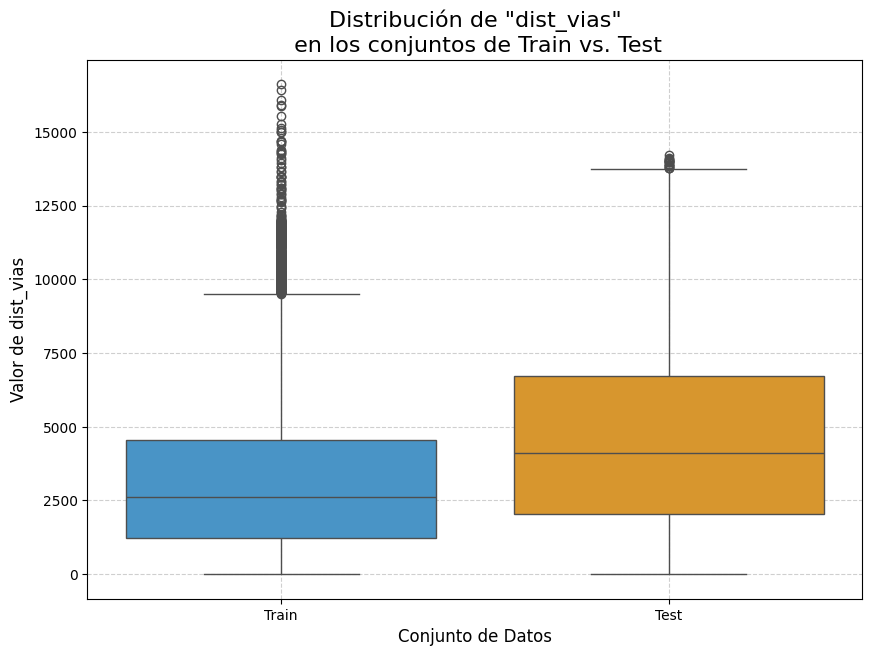

C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\3464090910.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test


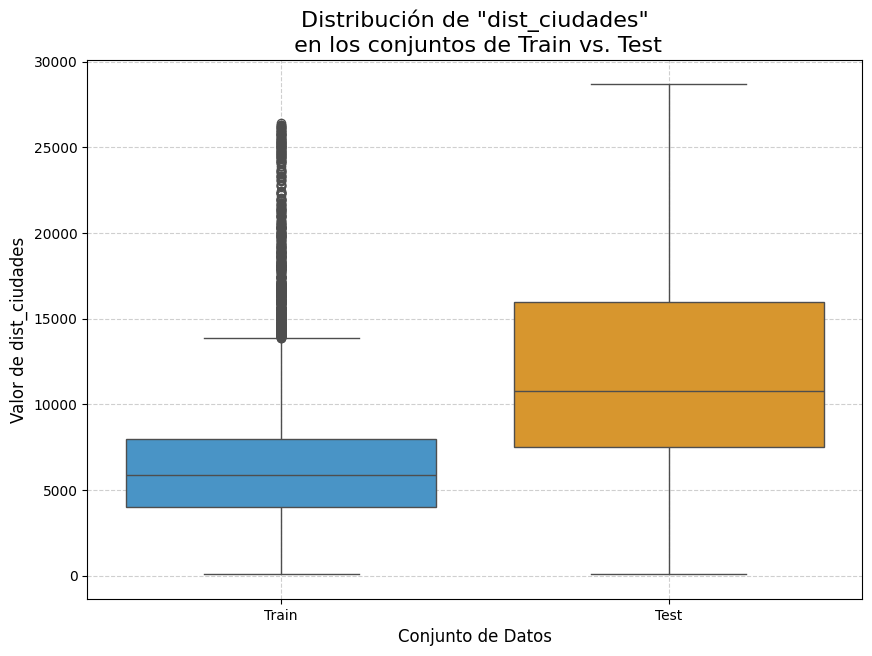

--- ANÁLISIS DE SANIDAD DE LA PARTICIÓN COMPLETADO ---
Los gráficos de comparación han sido guardados en: outputs\2025-12-30_04-14-49


In [52]:
print("\n--- INICIANDO ANÁLISIS DE SANIDAD DE LA PARTICIÓN TRAIN/TEST ---")
print("Comparando la distribución de variables entre el conjunto de entrenamiento y prueba...")

# 1. Crear un DataFrame combinado para facilitar la visualización
# Añadimos una columna a cada subconjunto para saber su origen
train_df_vis = train_df.copy()
train_df_vis['set'] = 'Train'

test_df_vis = test_df.copy()
test_df_vis['set'] = 'Test'

# Los concatenamos en un solo DataFrame
combined_df_vis = pd.concat([train_df_vis, test_df_vis], ignore_index=True)

# 2. Definir las variables numéricas que queremos comparar
# Asegúrate de que estas columnas existen en tus DataFrames
variables_numericas_a_comparar = [
    'elevacion', 
    'pendiente', 
    'ndvi', 
    'temperature', 
    'precipitation', 
    'humidity', 
    'wind_speed',
    'dist_vias', 
    'dist_ciudades'
]

# 3. Iterar sobre cada variable y crear un gráfico de cajas
for var in variables_numericas_a_comparar:
    plt.figure(figsize=(10, 7))
    sns.boxplot(x='set', y=var, data=combined_df_vis, palette=['#3498db', '#f39c12']) # Azul para Train, Naranja para Test
    
    # Añadir títulos y etiquetas para mayor claridad
    plt.title(f'Distribución de "{var}"\n en los conjuntos de Train vs. Test', fontsize=16)
    plt.xlabel('Conjunto de Datos', fontsize=12)
    plt.ylabel(f'Valor de {var}', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Guardar la figura en la carpeta de resultados
    # Asegúrate de que la variable OUTPUT_DIR esté definida como en tu script
    ruta_guardado = OUTPUT_DIR / f'boxplot_partition_{var}.png'
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    
    # Mostrar el gráfico en pantalla
    plt.show()

print("--- ANÁLISIS DE SANIDAD DE LA PARTICIÓN COMPLETADO ---")
print(f"Los gráficos de comparación han sido guardados en: {OUTPUT_DIR}")


## Guardado de resultados y visualización


--- Guardando resultados del modelo ---


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Reporte de clasificación guardado en: outputs\2025-12-30_04-14-49\classification_report.txt
Gráfico de rendimiento guardado en: outputs\2025-12-30_04-14-49\performance_plot.png


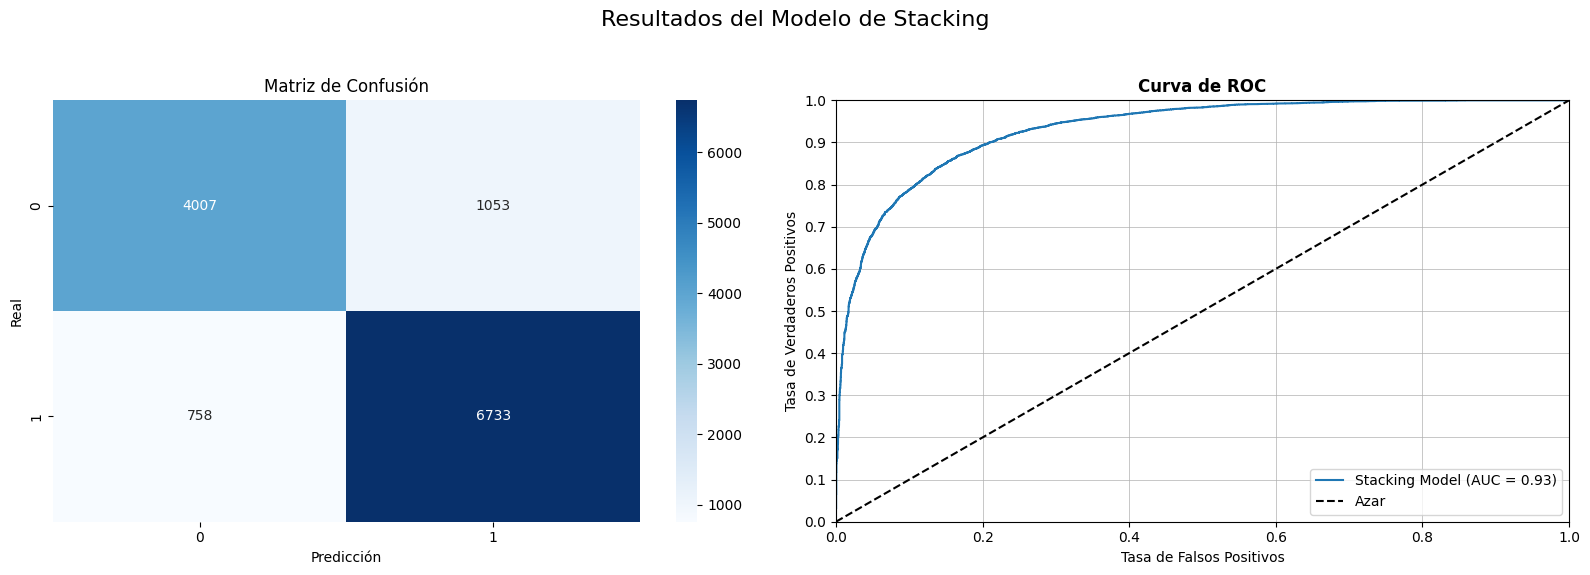

In [54]:
print("\n--- Guardando resultados del modelo ---")

# --- Guardar el reporte de clasificación en un archivo de texto ---
report = classification_report(y_test, y_pred, target_names=['No Incendio', 'Incendio'])
# --- Obtener predicciones del modelo de Stacking ---
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]  # Probabilidades de la clase positiva
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

report_path = OUTPUT_DIR / "classification_report.txt"
with open(report_path, "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"ROC AUC Score: {roc_auc:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
print(f"Reporte de clasificación guardado en: {report_path}")

# --- Crear y guardar el gráfico combinado (Matriz de Confusión y Curva ROC) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Resultados del Modelo de Stacking', fontsize=16)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title("Matriz de Confusión")
ax1.set_xlabel("Predicción")
ax1.set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax2.plot(fpr, tpr, label=f'Stacking Model (AUC = {roc_auc:.2f})')
ax2.plot([0, 1], [0, 1], 'k--', label='Azar')
ax2.set_title('Curva de ROC', fontweight='bold')
ax2.set_xlabel('Tasa de Falsos Positivos')
ax2.set_ylabel('Tasa de Verdaderos Positivos')
ax2.legend()
ax2.set_yticks(np.arange(0, 1.1, 0.1))
ax2.set_xticks(np.arange(0, 1.1, 0.2))
ax2.grid(True, which='both', linestyle='-', linewidth=0.5)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.0])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el supertítulo

# Guardar la figura
plot_path = OUTPUT_DIR / "performance_plot.png"
plt.savefig(plot_path, dpi=300)
print(f"Gráfico de rendimiento guardado en: {plot_path}")

# Mostrar el gráfico en pantalla
plt.show()


## Análisis de explicabilidad del modelo (SHAP)

f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- INICIANDO FASE DE EXPLICABILIDAD CON SHAP ---
>>> EJECUTANDO EN MODO FINAL (LENTO) CON UNA MUESTRA MÁS GRANDE <<<
Entrenando un modelo Random Forest 'proxy' para el análisis SHAP...
Modelo proxy entrenado.
Explicador TreeExplainer de SHAP creado.
Calculando las explicaciones SHAP para 2000 muestras...
Cálculo de explicaciones SHAP completado.
Generando gráficos de SHAP...


C:\Users\usuario\AppData\Local\Temp\ipykernel_11980\2207827945.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_object[:,:,1], X_test_sample_df, plot_type="dot", show=False)


Gráfico de resumen SHAP guardado en: outputs\2025-09-05_20-27-08\shap_summary_plot_rf.png


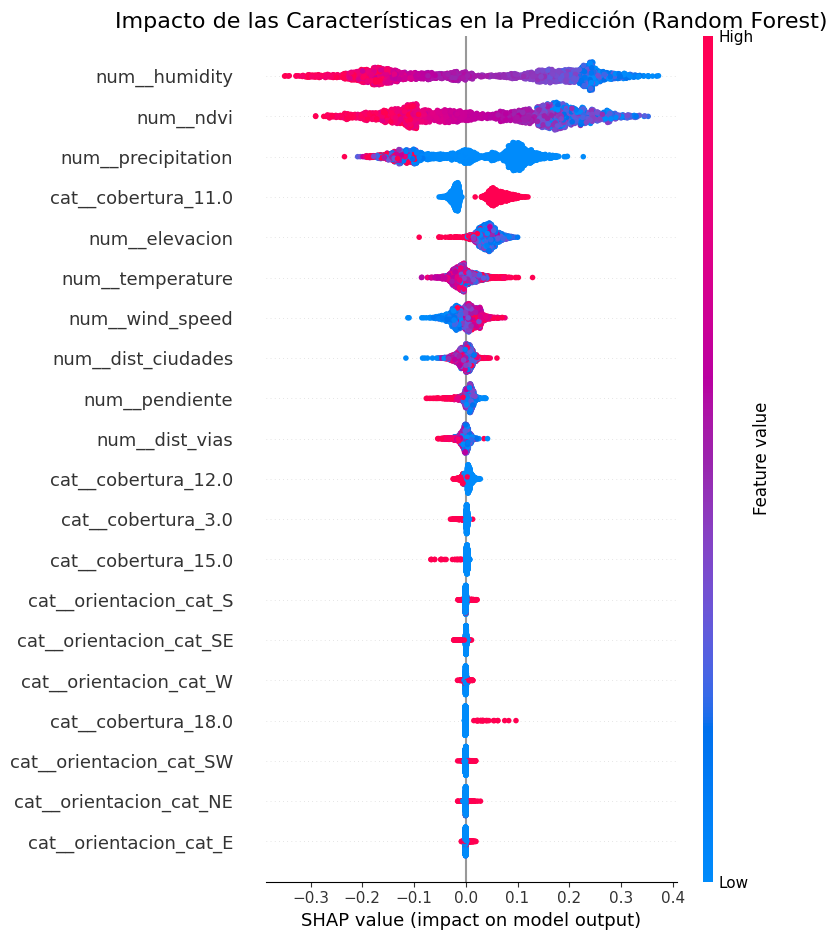

C:\Users\usuario\AppData\Local\Temp\ipykernel_11980\2207827945.py:72: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_object[:,:,1], X_test_sample_df, plot_type="bar", show=False)


Gráfico de barras SHAP guardado en: outputs\2025-09-05_20-27-08\shap_bar_plot_rf.png


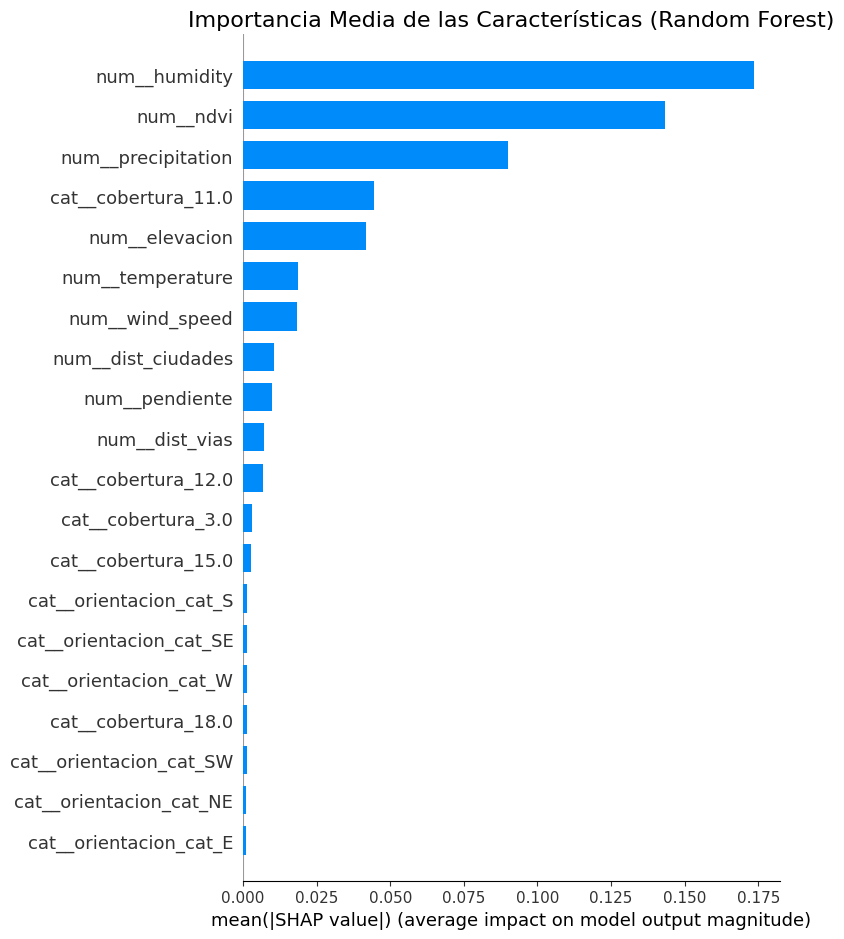

In [26]:
import shap


print("\n--- INICIANDO FASE DE EXPLICABILIDAD CON SHAP ---")

# --- Configuración para el modo de ejecución ---
MODO_BORRADOR = False

if MODO_BORRADOR:
    print(">>> EJECUTANDO EN MODO BORRADOR (RÁPIDO) CON UNA MUESTRA PEQUEÑA <<<")
    n_muestras_shap = 500
else:
    print(">>> EJECUTANDO EN MODO FINAL (LENTO) CON UNA MUESTRA MÁS GRANDE <<<")
    n_muestras_shap = min(len(X_test), 2000) # Usar hasta 2000 muestras para el plot final


# --- 5.7.1. Preparar datos y modelo ---

# Extraemos el preprocesador y el modelo RandomForest ya entrenados
preprocessor_trained = full_pipeline.named_steps['preprocessor']
rf_model_trained = full_pipeline.named_steps['classifier'].estimators_[0]

# Preprocesamos los datos de prueba
X_test_processed = preprocessor_trained.transform(X_test)

# Obtenemos los nombres de las características de forma segura
feature_names = preprocessor_trained.get_feature_names_out()

# Convertimos a DataFrame y tomamos nuestra muestra
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)
X_test_sample_df = X_test_processed_df.sample(n=n_muestras_shap, random_state=seed)


# --- 5.7.2. Entrenar Modelo Proxy, Crear Explicador y Calcular Explicaciones ---

# Entrenamos un modelo proxy idéntico para asegurar compatibilidad total
print("Entrenando un modelo Random Forest 'proxy' para el análisis SHAP...")
rf_proxy_model = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
rf_proxy_model.fit(preprocessor_trained.transform(X_train), y_train)
print("Modelo proxy entrenado.")

# Creamos el explicador con el modelo proxy
explainer = shap.TreeExplainer(rf_proxy_model)
print("Explicador TreeExplainer de SHAP creado.")

print(f"Calculando las explicaciones SHAP para {n_muestras_shap} muestras...")

explanation_object = explainer(X_test_sample_df)
print("Cálculo de explicaciones SHAP completado.")


# --- 5.7.3. Generar y Guardar los Gráficos de Explicabilidad ---

print("Generando gráficos de SHAP...")

# Para un clasificador binario, el objeto Explanation tiene 3 dimensiones: (muestras, características, clases)
# Queremos las explicaciones para la clase 1 ("Incendio").
# Podemos acceder a ellas con la sintaxis de slicing: explanation_object[:,:,1]

# A. Gráfico de Resumen (Beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(explanation_object[:,:,1], X_test_sample_df, plot_type="dot", show=False)
plt.title("Impacto de las Características en la Predicción (Random Forest)", fontsize=16)
plt.tight_layout()
shap_summary_path = OUTPUT_DIR / "shap_summary_plot_rf.png"
plt.savefig(shap_summary_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de resumen SHAP guardado en: {shap_summary_path}")
plt.show()

# B. Gráfico de Barras de Importancia Media
plt.figure(figsize=(10, 8))
shap.summary_plot(explanation_object[:,:,1], X_test_sample_df, plot_type="bar", show=False)
plt.title("Importancia Media de las Características (Random Forest)", fontsize=16)
plt.tight_layout()
shap_bar_path = OUTPUT_DIR / "shap_bar_plot_rf.png"
plt.savefig(shap_bar_path, dpi=300, bbox_inches='tight')
print(f"Gráfico de barras SHAP guardado en: {shap_bar_path}")
plt.show()

## Aplicación: Mapa de riesgo de incendios forestales


--- INICIANDO FASE DE APLICACIÓN: MAPA DE RIESGO ---
Se generaron 17166 puntos en la rejilla para la predicción.

--- INICIANDO FASE DE ASIGNACIÓN DE VARIABLES ---
Asignando variables topográficas...
Reproyectando DEM para cálculo de pendiente/orientación...
Asignando Cobertura del Suelo por año...
Asignando NDVI desde archivos mensuales...
Asignando variables meteorológicas...
Añadiendo características de proximidad...
Asignación de variables completada.
Prediciendo el riesgo para 17166 puntos válidos.

Tabla de predicciones guardada en: outputs\2025-09-05_20-27-08\predicciones_riesgo.csv
Interpolando resultados para crear mapa de calor...
Mapa de calor final guardado en: outputs\2025-09-05_20-27-08\risk_map_heatmap_final.png


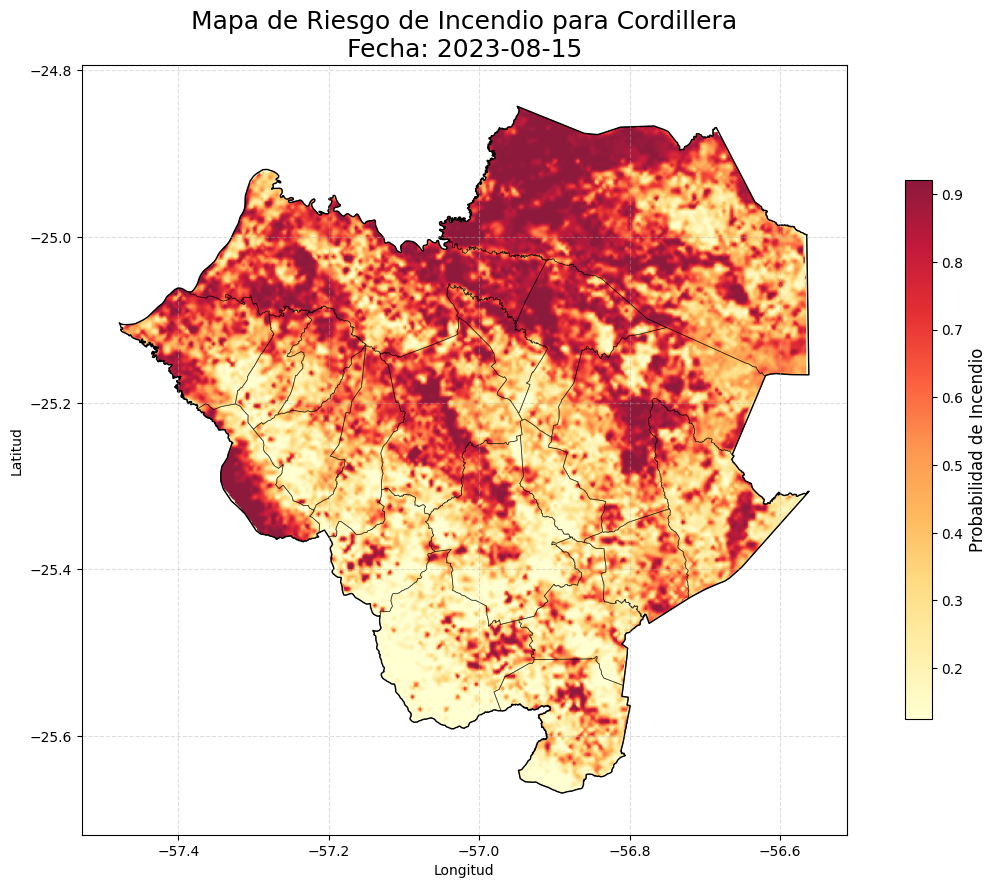

In [27]:
print("\n--- INICIANDO FASE DE APLICACIÓN: MAPA DE RIESGO ---")
cell_size = 0.005 
minx, miny, maxx, maxy = study_area_bounds
xv, yv = np.meshgrid(np.arange(minx, maxx, cell_size), np.arange(miny, maxy, cell_size))
grid_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xv.ravel(), yv.ravel()), crs=CRS_REFERENCE)
grid_en_area = grid_gdf[grid_gdf.within(study_area_polygon)].copy()

if grid_en_area.empty:
    print("\nADVERTENCIA: No se generaron puntos en la rejilla.")
else:
    print(f"Se generaron {len(grid_en_area)} puntos en la rejilla para la predicción.")
    fecha_prediccion = pd.to_datetime("2023-08-15")
    grid_en_area.loc[:, 'date'] = fecha_prediccion
    weather_pred = weather_data
    
    grid_con_variables_raw = asignar_variables(grid_en_area, MERGED_DEM_PATH, COBERTURA_DIR, NDVI_DIR, weather_pred, VIAS_SHP_PATH, CIUDADES_SHP_PATH)
    grid_con_variables = grid_con_variables_raw.dropna()
    
    if not grid_con_variables.empty:
        print(f"Prediciendo el riesgo para {len(grid_con_variables)} puntos válidos.")
        X_grid = grid_con_variables[X_train.columns]
        prob_incendio = full_pipeline.predict_proba(X_grid)[:, 1]
        grid_con_variables['prob_incendio'] = prob_incendio
        # >>> INICIO DEL CÓDIGO PARA EXPORTAR CSV <<<
        
        # 1. Añadir columnas de longitud y latitud para el formato CSV
        # Extraemos las coordenadas X e Y de la columna de geometría.
        grid_con_variables['longitud'] = grid_con_variables.geometry.x
        grid_con_variables['latitud'] = grid_con_variables.geometry.y
        
        # 2. Seleccionar las columnas relevantes para el frontend
        # Creamos una lista para que sea fácil añadir o quitar variables en el futuro.
        columnas_para_exportar = [
            'longitud', 
            'latitud', 
            'prob_incendio', 
            'elevacion', 
            'pendiente', 
            'ndvi', 
            'temperature', 
            'precipitation', 
            'humidity', 
            'wind_speed',
            'dist_vias', 
            'dist_ciudades',
            'cobertura',
            'orientacion_cat'
        ]
        
        # Creamos el DataFrame final con solo las columnas deseadas.
        df_para_exportar = grid_con_variables[columnas_para_exportar]
        
        # 3. Definir la ruta y guardar el archivo CSV
        # Usamos la variable OUTPUT_DIR que ya está definida para guardar en la carpeta correcta.
        ruta_csv_riesgo = OUTPUT_DIR / "predicciones_riesgo.csv"
        df_para_exportar.to_csv(ruta_csv_riesgo, index=False, float_format='%.6f')
        
        # 4. Imprimir un mensaje de confirmación en la terminal
        print(f"\nTabla de predicciones guardada en: {ruta_csv_riesgo}")
        
        # >>> FIN DEL CÓDIGO PARA EXPORTAR CSV <<<
        fig, ax = plt.subplots(1, 1, figsize=(15, 10))

        # --- 1. Preparar datos para la interpolación ---
        points = np.array([grid_con_variables.geometry.x, grid_con_variables.geometry.y]).T
        values = grid_con_variables['prob_incendio'].values
        
        vmin = pd.Series(values).quantile(0.05)
        vmax = pd.Series(values).quantile(0.95)

        minx, miny, maxx, maxy = area_estudio_gdf.total_bounds
        grid_x, grid_y = np.mgrid[minx:maxx:500j, miny:maxy:500j]

        print("Interpolando resultados para crear mapa de calor...")
        interpolated_grid = griddata(points, values, (grid_x, grid_y), method='cubic')
        interpolated_grid = np.nan_to_num(interpolated_grid, nan=vmin)

        # --- 2. Dibujar el mapa de calor interpolado ---
        im = ax.imshow(
            interpolated_grid.T, 
            extent=(minx, maxx, miny, maxy), 
            origin='lower', 
            cmap='YlOrRd', 
            alpha=0.9,     
            vmin=vmin,      
            vmax=vmax       
        )
        # --- 3. Enmascarar el mapa de calor ---
        
        union_poly = area_estudio_gdf.union_all()
        path_verts, path_codes = [], []
        def add_polygon_to_path(polygon):
            path_verts.extend(np.asarray(polygon.exterior.coords.xy).T)
            path_codes.extend([mpath.Path.MOVETO] + [mpath.Path.LINETO] * (len(polygon.exterior.coords) - 1))
            for interior in polygon.interiors:
                path_verts.extend(np.asarray(interior.coords.xy).T)
                path_codes.extend([mpath.Path.MOVETO] + [mpath.Path.LINETO] * (len(interior.coords) - 1))
        
        if union_poly.geom_type == 'Polygon': add_polygon_to_path(union_poly)
        elif union_poly.geom_type == 'MultiPolygon':
            for poly in union_poly.geoms: add_polygon_to_path(poly)
        
        clip_path = mpath.Path(path_verts, path_codes)
        patch = PathPatch(clip_path, transform=ax.transData, facecolor='none')
        im.set_clip_path(patch)

        area_estudio_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
        gpd.read_file(DISTRITOS_SHP_PATH).to_crs(area_estudio_gdf.crs).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, alpha=0.6)
        
        # --- 5. Configuración final ---
        ax.set_title(f"Mapa de Riesgo de Incendio para Cordillera\nFecha: {fecha_prediccion.date()}", fontsize=18)
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.grid(True, linestyle='--', alpha=0.4)
        
        ax.set_xlim(minx - 0.05, maxx + 0.05)
        ax.set_ylim(miny - 0.05, maxy + 0.05)

        cbar = fig.colorbar(im, ax=ax, shrink=0.7)
        cbar.set_label('Probabilidad de Incendio', fontsize=12)

        risk_map_path = OUTPUT_DIR / "risk_map_heatmap_final.png"
        plt.savefig(risk_map_path, dpi=300, bbox_inches='tight')
        print(f"Mapa de calor final guardado en: {risk_map_path}")
        
        plt.show()
    else:
        print("\nERROR FINAL: No se pudo generar el mapa de riesgo. La rejilla quedó vacía después de la depuración.")
        print("Valores nulos encontrados en la rejilla antes de eliminar:\n", grid_con_variables_raw.isnull().sum())


## Configuración del Análisis Exploratorio de Datos (EDA) y gráficos

In [28]:
print("\n--- Guardando resultados del modelo para evaluación avanzada ---")

# Creamos un diccionario para guardar todo lo que necesitamos
results_for_eval = {
    'model': full_pipeline,
    'X_test': X_test,
    'y_test': y_test,
    'y_pred_proba': y_pred_proba
}

# Guardamos el diccionario en un archivo pickle
output_path_pkl = "resultados_modelo_para_eval.pkl"
with open(output_path_pkl, 'wb') as f:
    pickle.dump(results_for_eval, f)

print(f"Resultados del modelo guardados en: {output_path_pkl}")
# Guarda el dataframe para que el script de EDA pueda usarlo

datos_depurados.to_pickle("datos_depurados_para_eda.pkl")
print("DataFrame 'datos_depurados' guardado en datos_depurados_para_eda.pkl")


--- Guardando resultados del modelo para evaluación avanzada ---
Resultados del modelo guardados en: resultados_modelo_para_eval.pkl
DataFrame 'datos_depurados' guardado en datos_depurados_para_eda.pkl


### Librerías

In [56]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
from pathlib import Path
from datetime import datetime

### Rutas

In [57]:
# --- Rutas de entrada ---
# Archivo generado por tu script de modelado principal
DATOS_DEPURADOS_PKL = "datos_depurados_para_eda.pkl"
# Shapefile del límite del departamento para el mapa de densidad
DEPARTAMENTO_SHP_PATH = "data/COORDILLERA/Departamento_Coordillera.shp" 

# --- Carpeta de Salida ---
# Se creará una carpeta con este nombre para guardar los gráficos
OUTPUT_DIR = Path("outputs_analisis_exploratorio")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Los gráficos de EDA se guardarán en: {OUTPUT_DIR}")

# --- CRS Métrico ---
# Asegúrate de que sea el mismo que usas en tu script principal para consistencia
METRIC_CRS = "EPSG:32721"


Los gráficos de EDA se guardarán en: outputs_analisis_exploratorio


### Carga de datos

In [58]:
print(f"Cargando datos desde '{DATOS_DEPURADOS_PKL}'...")
try:
    datos_depurados = pd.read_pickle(DATOS_DEPURADOS_PKL)
    print("Datos cargados exitosamente.")
except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{DATOS_DEPURADOS_PKL}'.")
    print("Por favor, ejecuta tu script de modelado principal para generar este archivo.")
    exit()

# Separar los focos de incendio (casos positivos)
focos_incendio = datos_depurados[datos_depurados['fire'] == 1].copy()


Cargando datos desde 'datos_depurados_para_eda.pkl'...
Datos cargados exitosamente.


### Gráfico 1: Serie temporal de focos de incendios
Objetivo: Visualizar la estacionalidad y tendencias de los incendios.

Generando Gráfico 1: Serie Temporal de Focos de Calor...


C:\Users\usuario\AppData\Local\Temp\ipykernel_8696\1955482092.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  focos_por_mes = focos_incendio.set_index('date').resample('M').size()


Gráfico guardado en: outputs_analisis_exploratorio\grafico_eda_serie_temporal.png


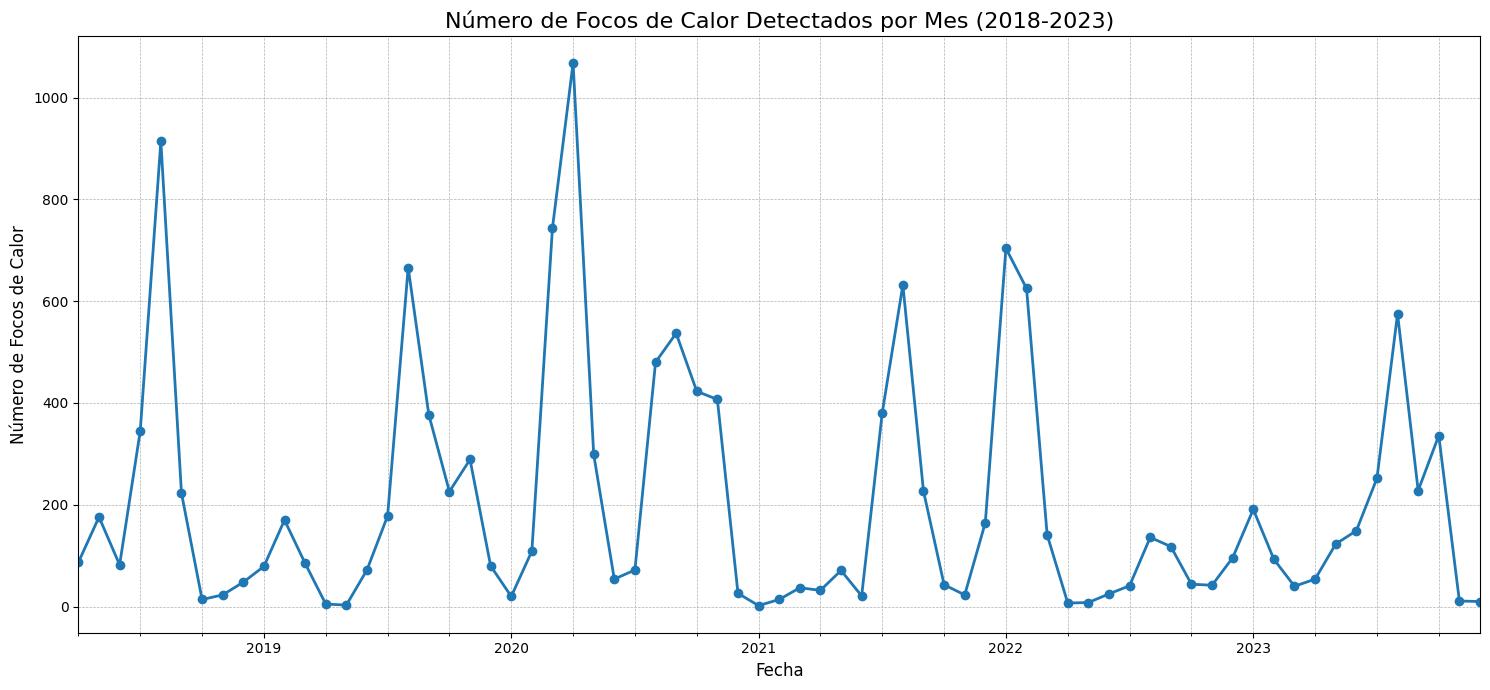

In [59]:
print("Generando Gráfico 1: Serie Temporal de Focos de Calor...")
# Asegurarnos que la columna 'date' es de tipo datetime
focos_incendio['date'] = pd.to_datetime(focos_incendio['date'])

# Agrupar los focos por mes y contarlos
focos_por_mes = focos_incendio.set_index('date').resample('M').size()

# Crear el gráfico
fig, ax = plt.subplots(figsize=(15, 7))
focos_por_mes.plot(ax=ax, linewidth=2, marker='o', linestyle='-')

# Estilo y etiquetas
ax.set_title('Número de Focos de Calor Detectados por Mes (2018-2023)', fontsize=16)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Número de Focos de Calor', fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

# Guardar el gráfico
ruta_guardado_ts = OUTPUT_DIR / "grafico_eda_serie_temporal.png"
plt.savefig(ruta_guardado_ts, dpi=300)
print(f"Gráfico guardado en: {ruta_guardado_ts}")
plt.show()

### Gráfico 2: Mapa de densidad de Kernel (Heatmap espacial)
Objetivo: Identificar visualmente las "zonas críticas" de alta concentración.

Generando Gráfico 2: Mapa de Densidad de Kernel...
Gráfico guardado en: outputs_analisis_exploratorio\mapa_eda_densidad_kernel.png


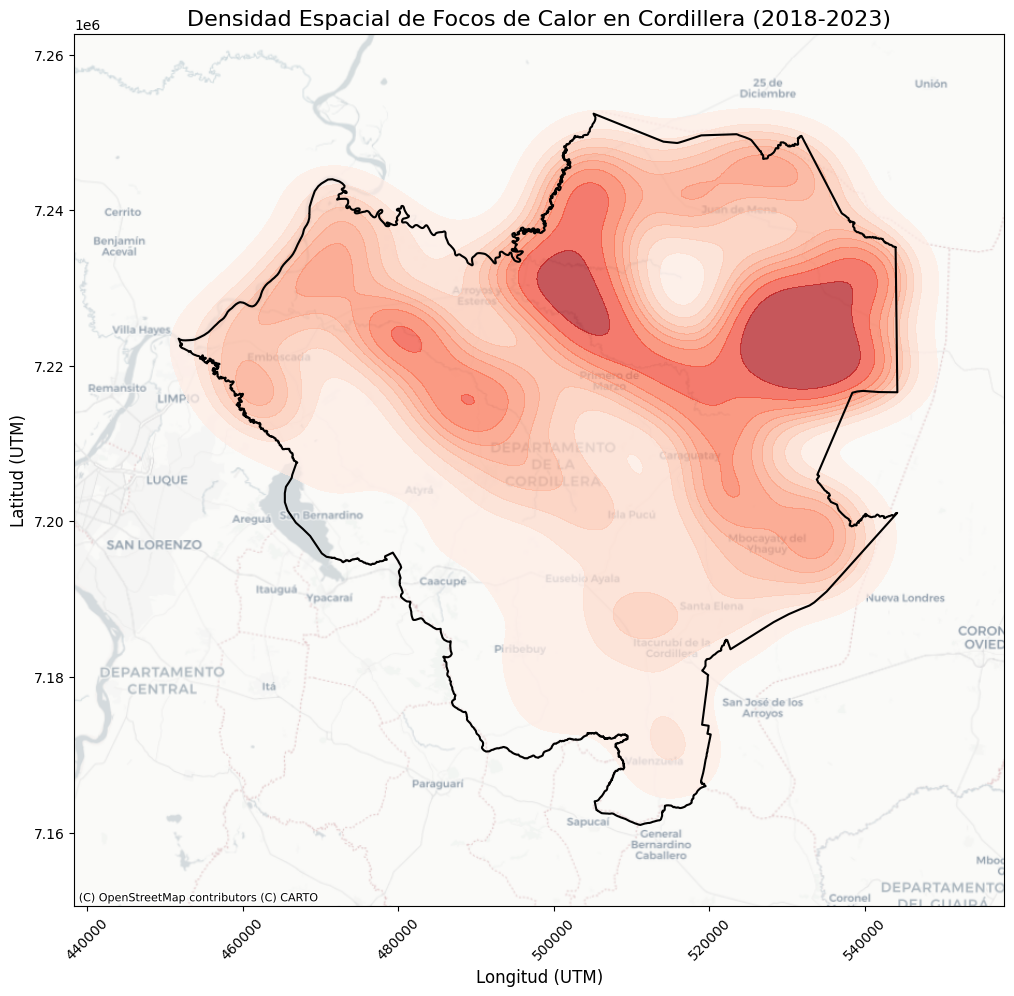

In [60]:
print("Generando Gráfico 2: Mapa de Densidad de Kernel...")
# Cargar el shapefile del departamento
departamento_gdf = gpd.read_file(DEPARTAMENTO_SHP_PATH)

# Reproyectar ambos GeoDataFrames a un CRS métrico para un análisis correcto
focos_metric = focos_incendio.to_crs(METRIC_CRS)
departamento_metric = departamento_gdf.to_crs(METRIC_CRS)

# Crear el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Dibujar el contorno del departamento
departamento_metric.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5, zorder=3)

# Generar y dibujar el mapa de densidad de kernel
sns.kdeplot(
    x=focos_metric.geometry.x,
    y=focos_metric.geometry.y,
    ax=ax,
    fill=True,          # Rellena las áreas de densidad
    cmap="Reds",        # Paleta de colores (rojos son buenos para calor)
    alpha=0.7,          # Transparencia
    levels=10,          # Número de contornos de densidad
    zorder=2
)

# Añadir un mapa base geográfico
cx.add_basemap(ax, crs=METRIC_CRS, source=cx.providers.CartoDB.Positron)

# Estilo y etiquetas
ax.set_title('Densidad Espacial de Focos de Calor en Cordillera (2018-2023)', fontsize=16)
ax.set_xlabel('Longitud (UTM)', fontsize=12)
ax.set_ylabel('Latitud (UTM)', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# Guardar el gráfico
ruta_guardado_kde = OUTPUT_DIR / "mapa_eda_densidad_kernel.png"
plt.savefig(ruta_guardado_kde, dpi=300, bbox_inches='tight')
print(f"Gráfico guardado en: {ruta_guardado_kde}")
plt.show()


### Gráfico 3: Matriz de correlación de variables predictoras
Objetivo: Evaluar relaciones lineales entre variables.

Generando Gráfico 3: Matriz de Correlación...
Gráfico guardado en: outputs_analisis_exploratorio\matriz_eda_correlacion.png


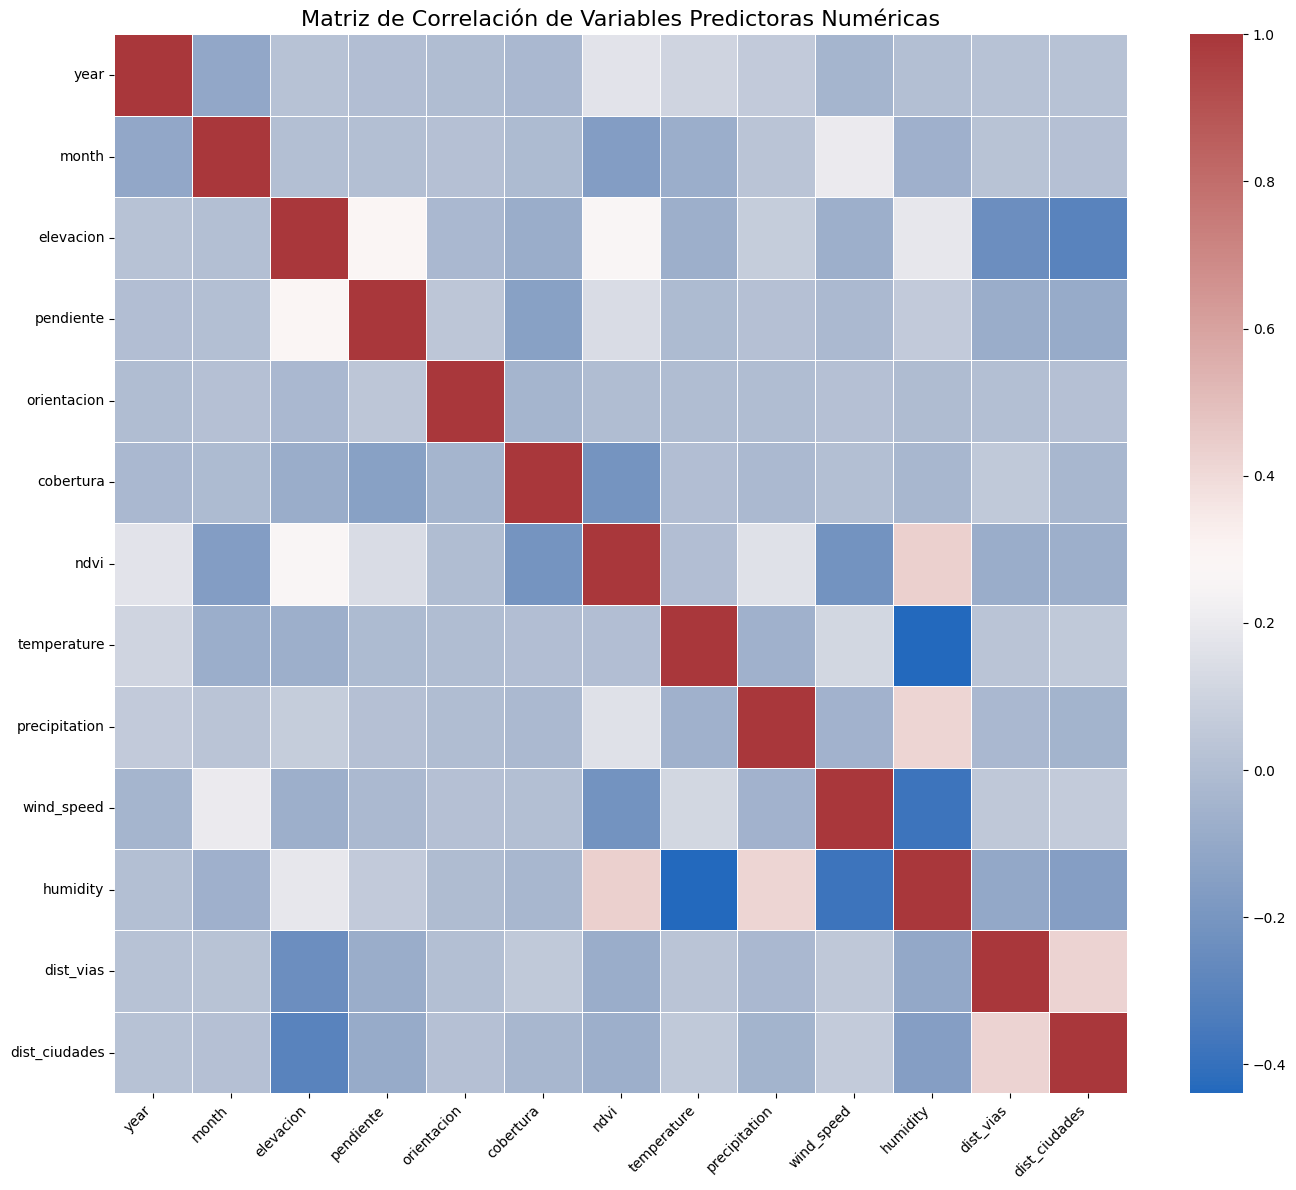


¡Análisis exploratorio completado!


In [34]:
print("Generando Gráfico 3: Matriz de Correlación...")
# Seleccionar solo las columnas numéricas que se usan como predictoras
variables_numericas = datos_depurados.select_dtypes(include=['number']).columns.tolist()
# Excluimos la variable objetivo 'fire' si está presente
if 'fire' in variables_numericas:
    variables_numericas.remove('fire')

# Calcular la matriz de correlación
matriz_correlacion = datos_depurados[variables_numericas].corr()

# Crear el gráfico (heatmap)
plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_correlacion,
    cmap='vlag',  # Paleta divergente: rojo (positivo), azul (negativo)
    annot=False,  # Poner en True si tienes pocas variables, sino se verá muy cargado
    linewidths=.5
)

# Estilo y etiquetas
plt.title('Matriz de Correlación de Variables Predictoras Numéricas', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar el gráfico
ruta_guardado_corr = OUTPUT_DIR / "matriz_eda_correlacion.png"
plt.savefig(ruta_guardado_corr, dpi=300)
print(f"Gráfico guardado en: {ruta_guardado_corr}")
plt.show()

print("\n¡Análisis exploratorio completado!")

## Gráficos de evaluación

Configuraciones

In [35]:
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

# Importaciones de Scikit-learn para los gráficos
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import CalibrationDisplay

MODEL_RESULTS_PKL = "resultados_modelo_para_eval.pkl"

# --- Carpeta de Salida ---
OUTPUT_DIR = Path("outputs_evaluacion_modelo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Los gráficos de evaluación del modelo se guardarán en: {OUTPUT_DIR}")


print(f"Cargando resultados del modelo desde '{MODEL_RESULTS_PKL}'...")
try:
    with open(MODEL_RESULTS_PKL, 'rb') as f:
        results = pickle.load(f)
    
    model = results['model']
    X_test = results['X_test']
    y_test = results['y_test']
    y_pred_proba = results['y_pred_proba']
    print("Resultados cargados exitosamente.")

except FileNotFoundError:
    print(f"ERROR: No se encontró el archivo '{MODEL_RESULTS_PKL}'.")
    print("Por favor, ejecuta tu script de modelado principal para generar este archivo.")
    exit()


Los gráficos de evaluación del modelo se guardarán en: outputs_evaluacion_modelo
Cargando resultados del modelo desde 'resultados_modelo_para_eval.pkl'...
Resultados cargados exitosamente.


### Gráfico 4: Curava de Precisión-Recall
Objetivo: Evaluar el trade-off entre la precisión y la capacidad de detectar todos los incendios reales. Esencial para problemas desbalanceados o donde los positivos son muy importantes.

Generando Gráfico 4: Curva de Precisión-Recall...
Gráfico guardado en: outputs_evaluacion_modelo\grafico_eval_precision_recall.png


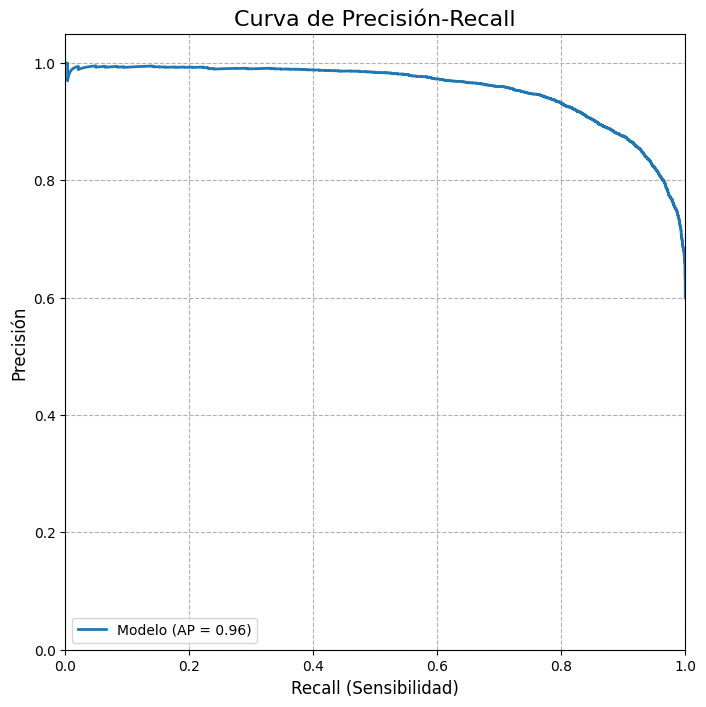

In [36]:
print("Generando Gráfico 4: Curva de Precisión-Recall...")

# Calcular los puntos de la curva
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

# Calcular el Average Precision Score (un único número que resume la curva)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Crear el gráfico
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall, precision, linewidth=2, label=f'Modelo (AP = {avg_precision:.2f})')

# Estilo y etiquetas
ax.set_title('Curva de Precisión-Recall', fontsize=16)
ax.set_xlabel('Recall (Sensibilidad)', fontsize=12)
ax.set_ylabel('Precisión', fontsize=12)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, linestyle='--')
ax.legend(loc='lower left')

# Guardar el gráfico
ruta_guardado_pr = OUTPUT_DIR / "grafico_eval_precision_recall.png"
plt.savefig(ruta_guardado_pr, dpi=300)
print(f"Gráfico guardado en: {ruta_guardado_pr}")
plt.show()


### Gráfico 5: Gráfico de calibración
Objetivo: Verificar si las probabilidades predichas por el modelo son fiables. (Ej: Si el modelo dice "80% de riesgo", ¿realmente ocurre un incendio el 80% de las veces en esas condiciones?)

Generando Gráfico 5: Gráfico de Calibración...
Gráfico guardado en: outputs_evaluacion_modelo\grafico_eval_calibracion.png


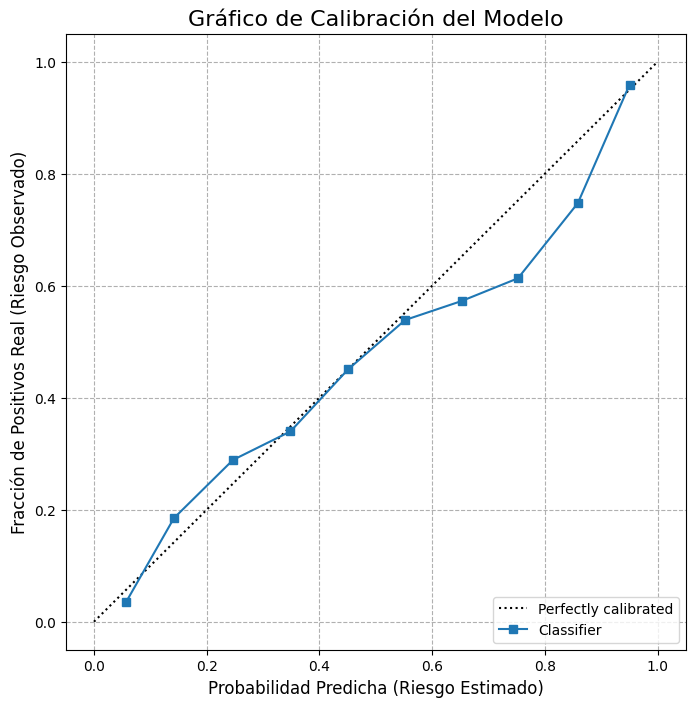


¡Generación de gráficos de evaluación completada!


In [37]:
print("Generando Gráfico 5: Gráfico de Calibración...")

# Crear el gráfico
# Usamos la nueva API de Scikit-learn que lo hace todo automáticamente
fig, ax = plt.subplots(figsize=(8, 8))
display = CalibrationDisplay.from_predictions(
    y_test, 
    y_pred_proba, 
    n_bins=10, # Dividir las predicciones en 10 grupos de riesgo
    ax=ax
)

# Estilo y etiquetas
ax.set_title('Gráfico de Calibración del Modelo', fontsize=16)
ax.set_xlabel('Probabilidad Predicha (Riesgo Estimado)', fontsize=12)
ax.set_ylabel('Fracción de Positivos Real (Riesgo Observado)', fontsize=12)
ax.grid(True, linestyle='--')

# Guardar el gráfico
ruta_guardado_cal = OUTPUT_DIR / "grafico_eval_calibracion.png"
plt.savefig(ruta_guardado_cal, dpi=300, bbox_inches='tight')
print(f"Gráfico guardado en: {ruta_guardado_cal}")
plt.show()

print("\n¡Generación de gráficos de evaluación completada!")